# Text/Transcripts and Polls EDA

This notebook is split into two parts:

- **Part 1 — Midterm EDA (high-level, no candidate labels).** Dataset-level exploration of debate + newscast transcripts and the polling timeline. This is the slice intended for the Week-4 midterm presentation (Task 1).
- **Part 2 — Task 2 / 3 Preview.** Speaker diarization to assign candidate labels, then per-candidate / per-party analyses (vocabulary, similarity, poll deltas, topic ownership). Useful for the final report but **not** in scope for the midterm.

Required midterm key plots (all produced inside Part 1):
1. Poll timeline chart — Section 5.
2. Transcript length distributions — Section 3.
3. Pairwise transcript-embedding similarity — Section 10.


In [1]:
import os
import re
from collections import Counter
from itertools import combinations, permutations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)


## 1. Loading transcripts, polls, and party labels

In [2]:
FEAT_DIR = 'Project_Features'

CANDIDATES = [
    'Cotrim_Figueiredo', 'Filipe', 'Gouveia_Melo',
    'Marques_Mendes', 'Martins', 'Pinto', 'Seguro', 'Ventura',
]
JORNAL_LABEL = 'jornal/interview'

MONTH_NAME_TO_NUM = {
    'October': 10, 'November': 11, 'December': 12, 'January': 1,
    'Oct': 10, 'Nov': 11, 'Dec': 12, 'Jan': 1,
}

def infer_event_year(month_num):
    return 2025 if month_num >= 10 else 2026


def parse_event_date(video_name):
    """Parse dates from debate names and Telejornal_RTP/TVI_{Nov|Dec|Jan}_day names."""
    parts = str(video_name).split('_')
    for i, part in enumerate(parts[:-1]):
        if part in MONTH_NAME_TO_NUM:
            try:
                day = int(parts[i + 1])
            except ValueError:
                continue
            month = MONTH_NAME_TO_NUM[part]
            return pd.Timestamp(year=infer_event_year(month), month=month, day=day)
    return None


def load_speech_feature_files(files, source_type):
    frames = []
    for f in files:
        video = f.replace('_speech.pkl', '')
        df = pd.read_pickle(os.path.join(FEAT_DIR, f)).copy()
        df['video'] = video
        df['source_type'] = source_type
        df['channel'] = video.split('_')[1] if video.startswith('Telejornal_') else 'debate'
        df['event_date'] = parse_event_date(video)
        df['event_label'] = video
        df['source_group'] = np.where(
            df['source_type'].eq('jornal'),
            'News reports',
            'Debates',
        )
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


debate_speech_files = sorted(
    f for f in os.listdir(FEAT_DIR)
    if f.endswith('_speech.pkl') and not f.startswith('Telejornal_')
)
jornal_speech_files = sorted(
    f for f in os.listdir(FEAT_DIR)
    if f.endswith('_speech.pkl') and f.startswith('Telejornal_')
)

debate_speech = load_speech_feature_files(debate_speech_files, 'debate')
jornal_speech = load_speech_feature_files(jornal_speech_files, 'jornal')
speech_all = pd.concat([debate_speech, jornal_speech], ignore_index=True, sort=False)

# Backwards-compatible name for debate-only candidate labeling sections.
speech = debate_speech.copy()

polls = pd.read_pickle(os.path.join(FEAT_DIR, 'polls_timeline.pkl'))

# Lightweight transcript metrics for Part 1 (no candidate labels needed).
speech_all['word_count'] = speech_all['transcript'].fillna('').str.split().str.len()
speech_all['char_count'] = speech_all['transcript'].fillna('').str.len()
speech_all['words_per_sec'] = speech_all['word_count'] / speech_all['duration'].replace(0, np.nan)
parties = pd.read_pickle(os.path.join(FEAT_DIR, 'candidate_party.pkl'))
candidate_to_party = dict(zip(parties['Candidate'], parties['Party']))

print(f'{len(debate_speech)} debate speech segments across {debate_speech["video"].nunique()} debates')
print(f'{len(jornal_speech)} jornal/interview speech segments across {jornal_speech["video"].nunique()} broadcasts')
print(f'{len(speech_all)} total speech segments across {speech_all["video"].nunique()} videos')
print(f'speech columns: {list(speech_all.columns)}')
print(f'\npolls: {polls.shape}, sources: {polls["Poll_source"].nunique()}')
print('parties:')
print(parties)


843 debate speech segments across 28 debates
564 jornal/interview speech segments across 14 broadcasts
1407 total speech segments across 42 videos
speech columns: ['timestamp', 'duration', 'transcript', 'text_embedding', 'video', 'source_type', 'channel', 'event_date', 'event_label', 'source_group', 'word_count', 'char_count', 'words_per_sec']

polls: (13, 10), sources: 5
parties:
           Candidate        Party
0       Gouveia_Melo  Independent
1     Marques_Mendes      PSD+CDS
2             Seguro           PS
3            Ventura           CH
4  Cotrim_Figueiredo           IL
5             Filipe          CDU
6            Martins           BE
7              Pinto            L


## 2. Dataset inventory & sanity checks

One-shot summary of what we have before any modeling. Counts, totals, embedding shapes, and the share of rows missing each key column.


In [3]:
inventory_rows = []
for label, df in [('Debates', debate_speech), ('News reports', jornal_speech), ('All', speech_all)]:
    inventory_rows.append({
        'group': label,
        'videos': df['video'].nunique() if len(df) else 0,
        'segments': len(df),
        'total_minutes': float(df['duration'].sum() / 60) if len(df) else 0.0,
        'total_words': int(df['word_count'].sum()) if 'word_count' in df else 0,
        'mean_words_per_segment': float(df['word_count'].mean()) if 'word_count' in df and len(df) else float('nan'),
        'mean_segment_seconds': float(df['duration'].mean()) if len(df) else float('nan'),
    })
inventory = pd.DataFrame(inventory_rows).set_index('group')
print('Dataset inventory:')
display(inventory.round(1))

# Embedding-shape sanity.
text_emb_shapes = speech_all['text_embedding'].apply(lambda v: tuple(np.asarray(v).shape)).unique()
print(f'Distinct transcript-embedding shapes: {list(text_emb_shapes)}  (expect [(4096,)])')

# Missing-rate per key column.
key_cols = ['transcript', 'duration', 'text_embedding', 'event_date', 'source_group', 'channel']
missing_rate = (
    speech_all[key_cols]
    .apply(lambda c: c.isna().mean() if c.dtype != object else (c.isna() | (c.astype(str).str.strip() == '')).mean())
    .rename('missing_rate')
    .to_frame()
)
print('\nPer-column missing rate (speech_all):')
display(missing_rate.round(4))

print(f'\nPolls: {polls.shape[0]} readings x {polls.shape[1]} columns; agencies: {polls["Poll_source"].nunique()}')
print(f'Candidates listed in polls table: {sum(1 for c in polls.columns if c not in ["date", "Poll_source"])}')
print(f'Candidate->party mapping rows: {len(parties)}')


Dataset inventory:


,videos,segments,total_minutes,total_words,mean_words_per_segment,mean_segment_seconds
group,,,,,,
Debates,28,843,572.4,0,NaN,40.7
News reports,14,564,385.9,0,NaN,41.0
All,42,1407,958.2,180457,128.3,40.9


Distinct transcript-embedding shapes: [(4096,)]  (expect [(4096,)])

Per-column missing rate (speech_all):


,missing_rate
transcript,0.0
duration,0.0
text_embedding,0.0
event_date,0.0
source_group,0.0
channel,0.0



Polls: 13 readings x 10 columns; agencies: 5
Candidates listed in polls table: 8
Candidate->party mapping rows: 8


## 3. Transcript length distributions  *(required key plot #2)*

Volume of speech per segment, video, and source. Aggregate-only — no candidate split here.


In [4]:
print('Per-segment summary (debates + news reports):')
print(speech_all[['word_count', 'char_count', 'duration', 'words_per_sec']].describe().round(2))

source_text_summary = (speech_all.groupby('source_group')
    .agg(videos=('video', 'nunique'),
         segments=('transcript', 'count'),
         total_words=('word_count', 'sum'),
         total_minutes=('duration', lambda s: s.sum() / 60),
         median_words=('word_count', 'median'),
         mean_words_per_sec=('words_per_sec', 'mean'))
    .sort_values('total_words', ascending=False))
print('\nTranscript volume summary by source:')
display(source_text_summary.round(2))


Per-segment summary (debates + news reports):
       word_count  char_count  duration  words_per_sec
count     1407.00      1407.0   1407.00        1407.00
mean       128.26      727.62     40.86           3.11
std         86.08      476.47     25.09           0.58
min         18.00       109.0     20.01           0.69
25%         75.00       428.5     24.64           2.69
50%        100.00       564.0     32.55           3.06
75%        147.00       830.0     46.36           3.51
max        712.00      3616.0    203.58           5.34

Transcript volume summary by source:


,videos,segments,total_words,total_minutes,median_words,mean_words_per_sec
source_group,,,,,,
Debates,28,843,117328,572.36,110.0,3.35
News reports,14,564,63129,385.85,85.0,2.74


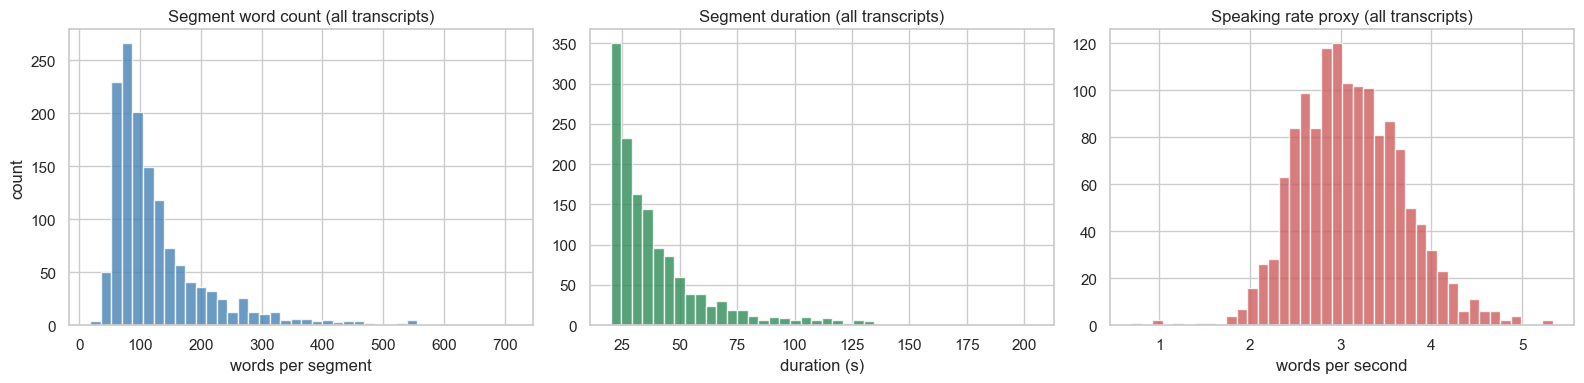

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(speech_all['word_count'], bins=40, color='steelblue', alpha=0.8)
axes[0].set_xlabel('words per segment'); axes[0].set_ylabel('count')
axes[0].set_title('Segment word count (all transcripts)')

axes[1].hist(speech_all['duration'], bins=40, color='seagreen', alpha=0.8)
axes[1].set_xlabel('duration (s)')
axes[1].set_title('Segment duration (all transcripts)')

axes[2].hist(speech_all['words_per_sec'].dropna(), bins=40, color='indianred', alpha=0.8)
axes[2].set_xlabel('words per second')
axes[2].set_title('Speaking rate proxy (all transcripts)')
plt.tight_layout(); plt.show()


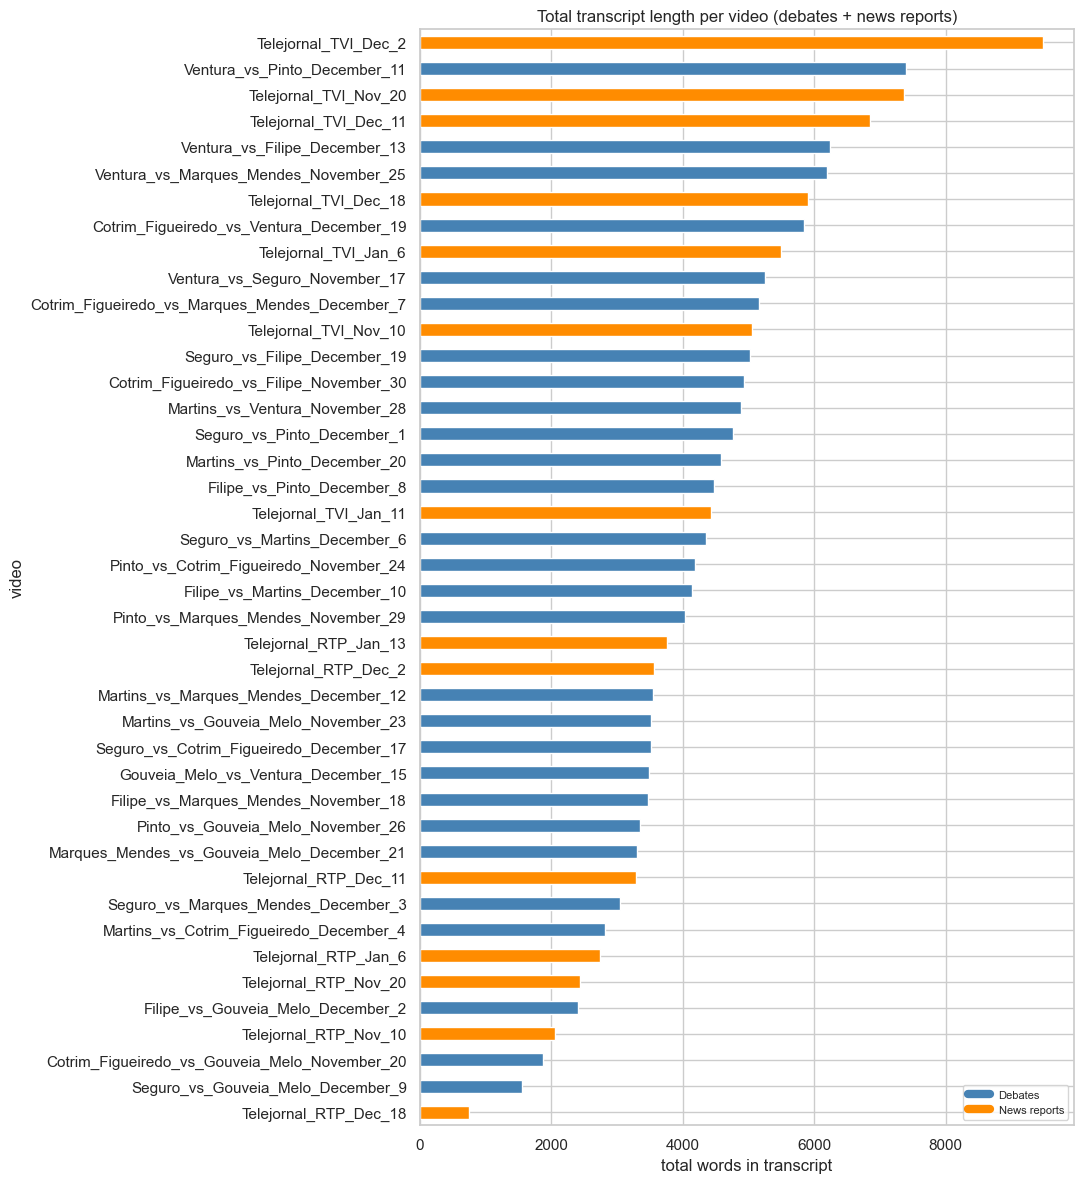

In [6]:
source_color_map = {'Debates': 'steelblue', 'News reports': 'darkorange'}

video_totals = (speech_all.groupby('video')
    .agg(total_words=('word_count', 'sum'),
         source_group=('source_group', 'first'),
         event_date=('event_date', 'first'))
    .sort_values('total_words', ascending=True))

fig, ax = plt.subplots(figsize=(11, 12))
bar_colors = [source_color_map.get(src, 'gray') for src in video_totals['source_group']]
video_totals['total_words'].plot(kind='barh', color=bar_colors, ax=ax)
ax.set_xlabel('total words in transcript')
ax.set_title('Total transcript length per video (debates + news reports)')
legend_handles = [plt.Line2D([0], [0], color=color, lw=6, label=label)
                  for label, color in source_color_map.items()
                  if label in set(video_totals['source_group'])]
ax.legend(handles=legend_handles, fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()


## 4. Debate timing & spacing

Debate dates over the campaign window, gaps between consecutive debates, and the relationship to the **2026-01-18** election date.


Debates with parsed dates: 28
First debate: 2025-11-17
Last debate:  2025-12-21
Days from last debate to election (2026-01-18): 28

Gap (days) between consecutive debates:
count    27.00
mean      1.26
std       0.59
min       0.00
25%       1.00
50%       1.00
75%       1.50
max       3.00
Name: gap_days, dtype: float64


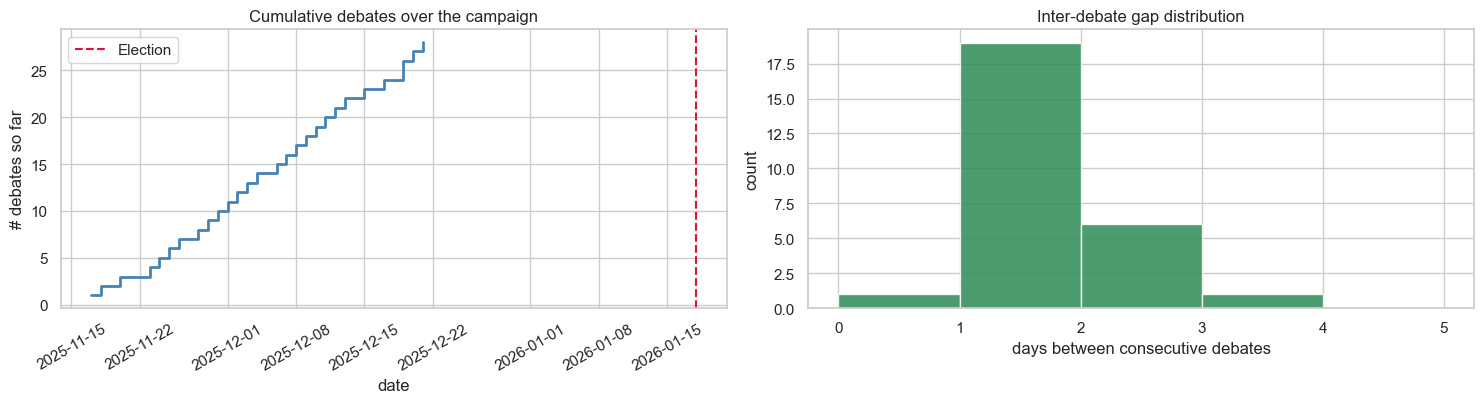

In [7]:
ELECTION_DATE = pd.Timestamp('2026-01-18')

debate_dates = (debate_speech[['video', 'event_date']]
                .drop_duplicates()
                .dropna()
                .sort_values('event_date')
                .reset_index(drop=True))

debate_dates['gap_days'] = debate_dates['event_date'].diff().dt.days

print(f'Debates with parsed dates: {len(debate_dates)}')
print(f'First debate: {debate_dates["event_date"].min().date()}')
print(f'Last debate:  {debate_dates["event_date"].max().date()}')
print(f'Days from last debate to election ({ELECTION_DATE.date()}): '
      f'{(ELECTION_DATE - debate_dates["event_date"].max()).days}')
print('\nGap (days) between consecutive debates:')
print(debate_dates['gap_days'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))

# (a) Cumulative debate count over time, with election overlay.
axes[0].step(debate_dates['event_date'],
             range(1, len(debate_dates) + 1),
             where='post', color='steelblue', linewidth=2)
axes[0].axvline(ELECTION_DATE, color='crimson', linestyle='--', linewidth=1.5, label='Election')
axes[0].set_xlabel('date'); axes[0].set_ylabel('# debates so far')
axes[0].set_title('Cumulative debates over the campaign')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# (b) Histogram of inter-debate gaps.
gaps = debate_dates['gap_days'].dropna()
axes[1].hist(gaps, bins=range(0, int(gaps.max()) + 3), color='seagreen', alpha=0.85, edgecolor='white')
axes[1].set_xlabel('days between consecutive debates'); axes[1].set_ylabel('count')
axes[1].set_title('Inter-debate gap distribution')

plt.tight_layout(); plt.show()


## 5. Polls timeline & agency coverage  *(required key plot #1)*

13 readings between October 2025 and January 2026 across 5 agencies. We parse dates, examine cadence and per-agency coverage, then plot the trajectories.


In [8]:
MONTH = {'October': 10, 'November': 11, 'December': 12, 'January': 1}
def parse_poll_date(s):
    parts = s.split('_')
    month, day = parts[0], int(parts[1])
    m = MONTH[month]
    return pd.Timestamp(year=infer_event_year(m), month=m, day=day)

polls = polls.copy()
polls['date_dt'] = polls['date'].apply(parse_poll_date)
polls = polls.sort_values('date_dt').reset_index(drop=True)

cand_cols = [c for c in polls.columns if c in CANDIDATES]
polls_long = polls.melt(
    id_vars=['date', 'date_dt', 'Poll_source'],
    value_vars=cand_cols, var_name='candidate', value_name='pct',
)
polls_long['party'] = polls_long['candidate'].map(candidate_to_party)
print(f'polls_long rows: {len(polls_long)}  (expected {len(polls)} x {len(cand_cols)} = {len(polls)*len(cand_cols)})')
polls_long.head()


polls_long rows: 104  (expected 13 x 8 = 104)


,date,date_dt,Poll_source,candidate,pct,party
0,October_13,2025-10-13,Pitagorica,Gouveia_Melo,26.9,Independent
1,October_30,2025-10-30,Intercampus,Gouveia_Melo,15.4,Independent
2,November_2,2025-11-02,Aximage,Gouveia_Melo,24.4,Independent
3,November_17,2025-11-17,Pitagorica,Gouveia_Melo,21.1,Independent
4,November_20,2025-11-20,Intercampus,Gouveia_Melo,15.5,Independent


Poll cadence summary:
       gap_days  pct_total
count     12.00      13.00
mean       7.75      87.35
std        7.07      10.49
min        0.00      68.00
25%        3.00      80.00
50%        5.00      88.70
75%       12.75      96.70
max       22.00      99.50

Polls per agency:
Poll_source
Intercampus    4
Pitagorica     3
Aximage        2
ICS/ISCTE      2
CESOP/UCP      2


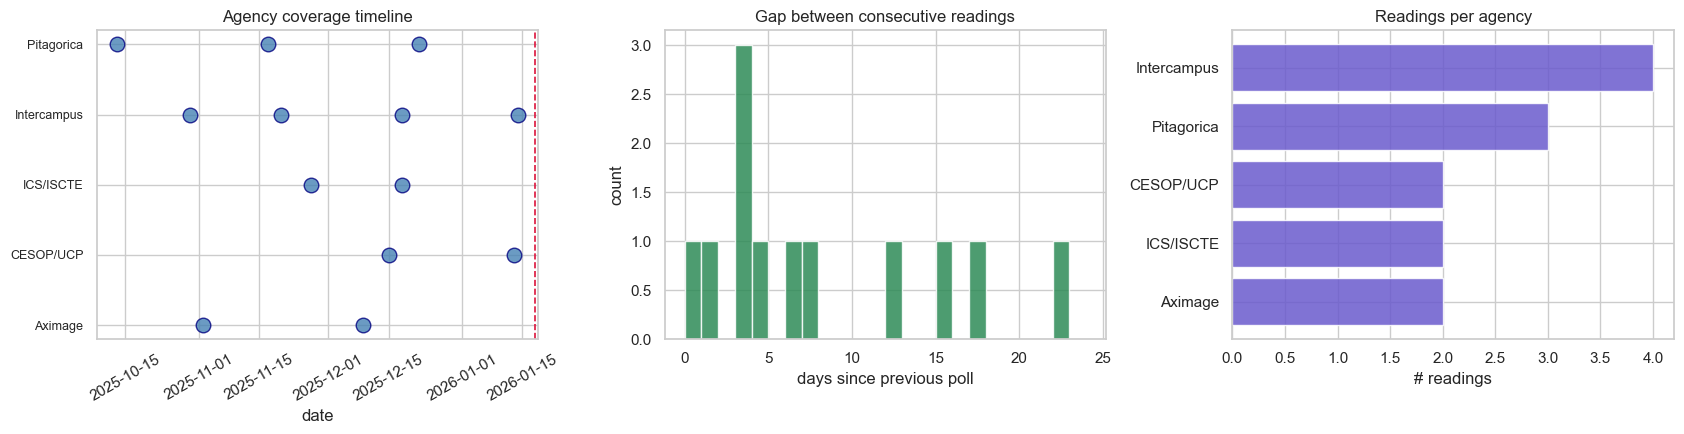


Per-row sum of candidate %: min=68.0, mean=87.3, max=99.5


In [9]:
cand_cols_local = [c for c in polls.columns if c in CANDIDATES]

poll_summary = polls[['date_dt', 'Poll_source']].copy()
poll_summary['gap_days'] = poll_summary.sort_values('date_dt')['date_dt'].diff().dt.days
poll_summary['pct_total'] = polls[cand_cols_local].sum(axis=1)

print('Poll cadence summary:')
print(poll_summary[['gap_days', 'pct_total']].describe().round(2))
print('\nPolls per agency:')
print(polls['Poll_source'].value_counts().to_string())

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) Calendar strip — agency x date.
agencies = sorted(polls['Poll_source'].unique())
agency_y = {ag: i for i, ag in enumerate(agencies)}
for _, row in polls.iterrows():
    axes[0].scatter(row['date_dt'], agency_y[row['Poll_source']],
                    s=110, color='steelblue', alpha=0.8, edgecolor='navy')
axes[0].set_yticks(list(agency_y.values()))
axes[0].set_yticklabels(list(agency_y.keys()), fontsize=9)
axes[0].axvline(ELECTION_DATE, color='crimson', linestyle='--', linewidth=1.2)
axes[0].set_xlabel('date'); axes[0].set_title('Agency coverage timeline')
axes[0].tick_params(axis='x', rotation=30)

# (b) Gap-between-readings histogram.
gaps = poll_summary['gap_days'].dropna()
axes[1].hist(gaps, bins=range(0, int(gaps.max()) + 3), color='seagreen', alpha=0.85, edgecolor='white')
axes[1].set_xlabel('days since previous poll'); axes[1].set_ylabel('count')
axes[1].set_title('Gap between consecutive readings')

# (c) Polls per agency.
ag_counts = polls['Poll_source'].value_counts().sort_values()
axes[2].barh(ag_counts.index, ag_counts.values, color='slateblue', alpha=0.85)
axes[2].set_xlabel('# readings'); axes[2].set_title('Readings per agency')

plt.tight_layout(); plt.show()

# Sanity check: percentages-per-row should sum near 100 (they don't have to exactly).
print(f'\nPer-row sum of candidate %: '
      f'min={poll_summary["pct_total"].min():.1f}, '
      f'mean={poll_summary["pct_total"].mean():.1f}, '
      f'max={poll_summary["pct_total"].max():.1f}')


In [10]:
# Default candidate colour map for Part 1 timeline plots.
# Part 2 (diarization) redefines a richer color_map; this gives Part 1 distinguishable lines.
_palette = sns.color_palette('tab10', len(CANDIDATES))
color_map = {c: _palette[i] for i, c in enumerate(CANDIDATES)}
color_map['interviewer'] = (0.6, 0.6, 0.6)
color_map['jornal/interview'] = 'darkorange'


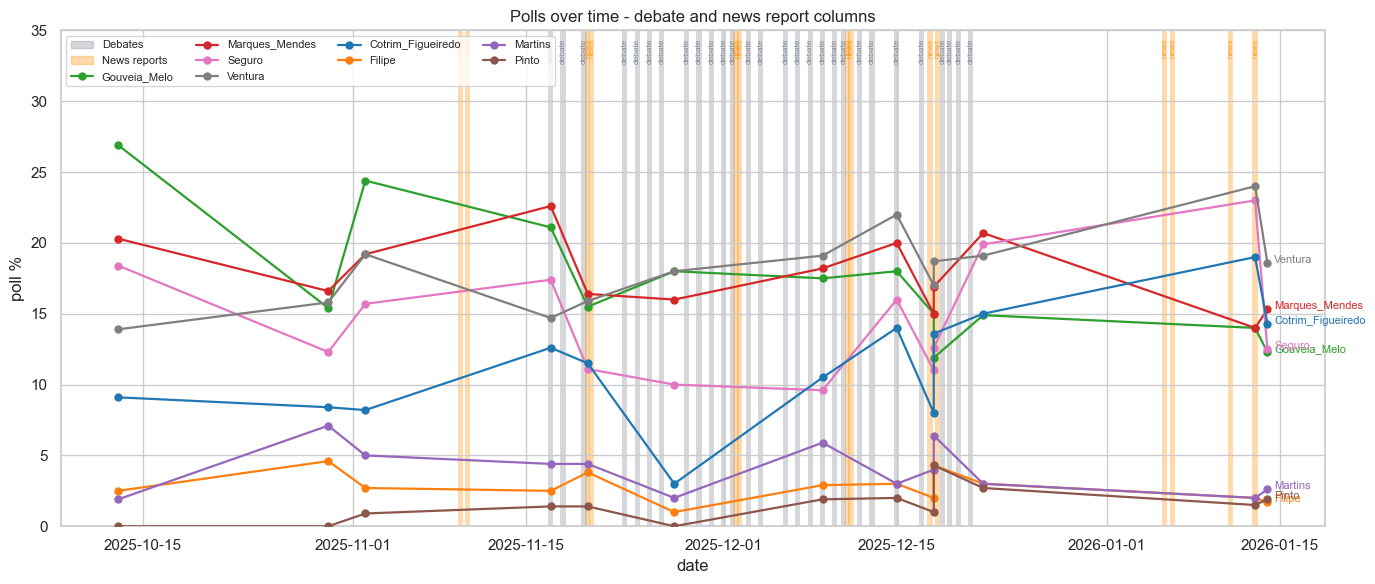

In [11]:
def event_date_from_video(video_name):
    if 'parse_event_date' in globals():
        parsed = parse_event_date(video_name)
        if parsed is not None:
            return parsed

    month_lookup = globals().get('MONTH_NAME_TO_NUM', {
        'October': 10, 'November': 11, 'December': 12, 'January': 1,
        'Oct': 10, 'Nov': 11, 'Dec': 12, 'Jan': 1,
    })
    parts = str(video_name).split('_')
    for i, part in enumerate(parts[:-1]):
        if part in month_lookup:
            try:
                day = int(parts[i + 1])
            except ValueError:
                continue
            month = month_lookup[part]
            year = 2025 if month >= 10 else 2026
            return pd.Timestamp(year=year, month=month, day=day)
    return None


def parse_debate_date(video_name):
    if 'extract_candidates' in globals():
        cA, cB = extract_candidates(video_name)
        is_debate = cA is not None and cB is not None
    else:
        is_debate = '_vs_' in str(video_name) and not str(video_name).startswith('Telejornal_')
    return event_date_from_video(video_name) if is_debate else None


feat_dir = globals().get('FEAT_DIR', 'Project_Features')
if 'debate_speech' in globals():
    debate_videos = debate_speech['video'].dropna().unique()
elif 'speech' in globals() and 'video' in speech.columns:
    debate_videos = speech['video'].dropna().unique()
else:
    debate_videos = [
        f.replace('_speech.pkl', '')
        for f in os.listdir(feat_dir)
        if f.endswith('_speech.pkl') and not f.startswith('Telejornal_')
    ]

debate_events = pd.DataFrame({'video': list(debate_videos)})
debate_events['event_date'] = debate_events['video'].apply(parse_debate_date)
debate_events['event_type'] = 'Debates'

if 'jornal_speech' in globals():
    news_report_events = jornal_speech[['video', 'event_date', 'channel']].copy()
elif 'speech_all_lab' in globals() and {'video', 'source_type'}.issubset(speech_all_lab.columns):
    news_report_events = speech_all_lab.loc[
        speech_all_lab['source_type'].eq('jornal'), ['video', 'event_date', 'channel']
    ].copy()
else:
    news_videos = [
        f.replace('_speech.pkl', '')
        for f in os.listdir(feat_dir)
        if f.endswith('_speech.pkl') and f.startswith('Telejornal_')
    ]
    news_report_events = pd.DataFrame({'video': news_videos})
    news_report_events['channel'] = news_report_events['video'].str.split('_').str[1]
    news_report_events['event_date'] = news_report_events['video'].apply(event_date_from_video)
news_report_events['event_type'] = 'News reports'

event_markers = pd.concat([
    debate_events[['video', 'event_date', 'event_type']],
    news_report_events[['video', 'event_date', 'event_type']],
], ignore_index=True)
event_markers = (event_markers
    .drop_duplicates()
    .dropna(subset=['event_date'])
    .sort_values(['event_date', 'event_type', 'video']))

plot_color_map = globals().get('color_map', {})
event_colors = {'Debates': '#6b7280', 'News reports': 'darkorange'}
event_alpha = {'Debates': 0.28, 'News reports': 0.32}
event_label_text = {'Debates': 'debate', 'News reports': 'news'}
column_width = pd.Timedelta(hours=10)
y_max = max(35, polls_long['pct'].max() + 3)

fig, ax = plt.subplots(figsize=(14, 6))
for event_date, group in event_markers.groupby('event_date'):
    offsets = np.linspace(-0.30, 0.30, len(group)) if len(group) > 1 else [0.0]
    for offset_days, (_, row) in zip(offsets, group.iterrows()):
        center = row['event_date'] + pd.to_timedelta(offset_days, unit='D')
        event_type = row['event_type']
        ax.axvspan(center - column_width / 2, center + column_width / 2,
                   color=event_colors.get(event_type, 'gray'),
                   alpha=event_alpha.get(event_type, 0.18),
                   linewidth=0, zorder=0)
        ax.text(center, y_max - 0.6, event_label_text.get(event_type, event_type),
                rotation=90, fontsize=6, ha='center', va='top',
                color=event_colors.get(event_type, 'gray'), alpha=0.75,
                clip_on=True, zorder=1)

for cand in cand_cols:
    sub = polls_long[polls_long['candidate'] == cand]
    ax.plot(sub['date_dt'], sub['pct'], marker='o', label=cand,
            color=plot_color_map.get(cand, 'gray'), linewidth=1.6, markersize=5, zorder=3)
    last = sub.iloc[-1]
    ax.annotate(cand, (last['date_dt'], last['pct']),
                fontsize=8, xytext=(5, 0), textcoords='offset points',
                color=plot_color_map.get(cand, 'gray'))

ax.set_ylabel('poll %'); ax.set_xlabel('date')
ax.set_title('Polls over time - debate and news report columns')
ax.set_ylim(0, y_max)
handles, labels = ax.get_legend_handles_labels()
event_handles = [
    plt.Rectangle((0, 0), 1, 1, color=event_colors['Debates'], alpha=event_alpha['Debates'], label='Debates'),
    plt.Rectangle((0, 0), 1, 1, color=event_colors['News reports'], alpha=event_alpha['News reports'], label='News reports'),
]
candidate_pairs = [(h, label) for h, label in zip(handles, labels) if label in cand_cols]
candidate_handles = [h for h, _ in candidate_pairs]
candidate_labels = [label for _, label in candidate_pairs]
ax.legend(event_handles + candidate_handles,
          ['Debates', 'News reports'] + candidate_labels,
          fontsize=8, ncol=4, loc='upper left')
plt.tight_layout(); plt.show()


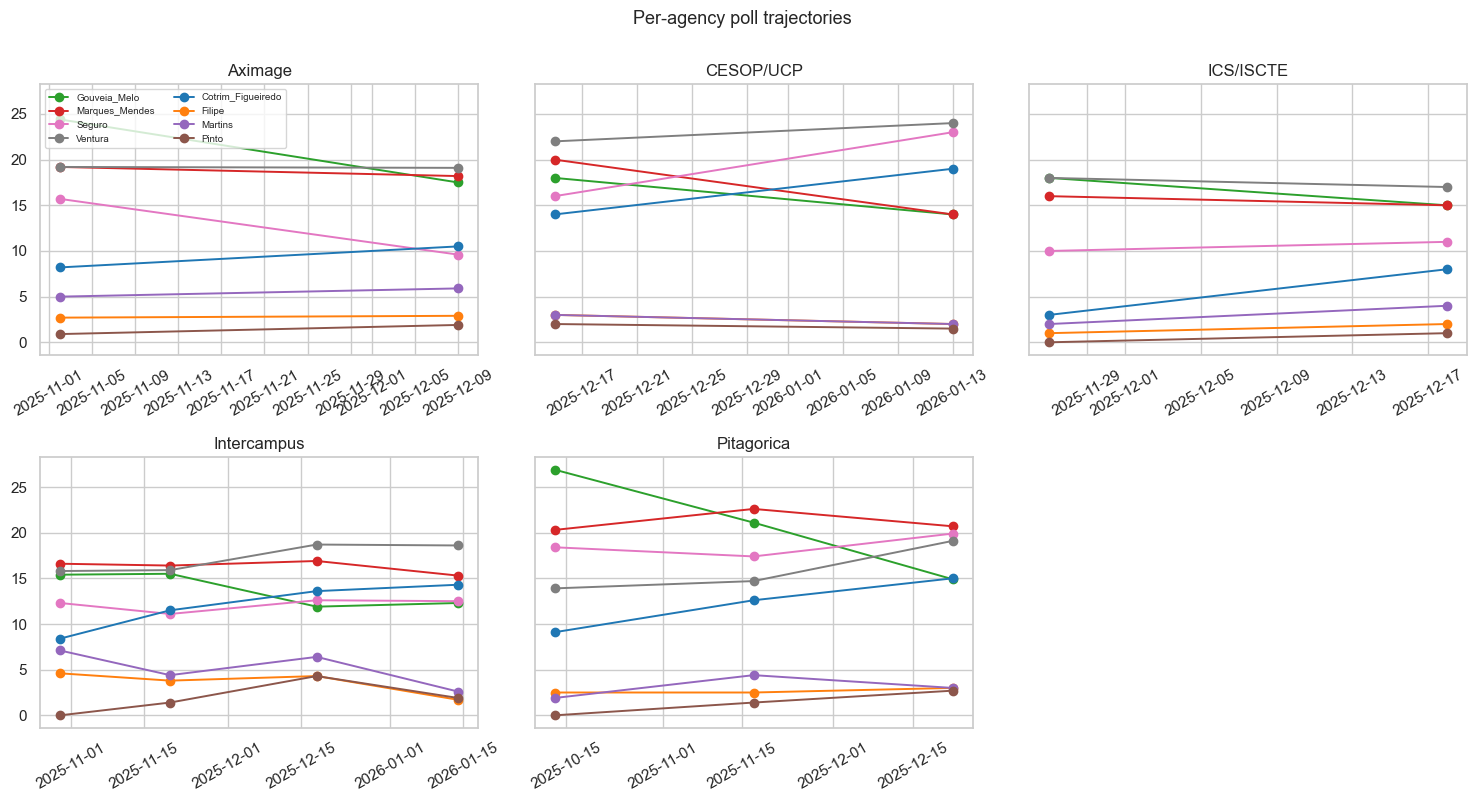

In [12]:
sources = sorted(polls['Poll_source'].unique())
ncols = 3
nrows = int(np.ceil(len(sources) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharey=True)
axes = axes.flatten()
for ax, src in zip(axes, sources):
    sub = polls_long[polls_long['Poll_source'] == src]
    for cand in cand_cols:
        s2 = sub[sub['candidate'] == cand]
        ax.plot(s2['date_dt'], s2['pct'], marker='o', label=cand,
                color=color_map.get(cand, 'gray'), linewidth=1.4)
    ax.set_title(src); ax.tick_params(axis='x', rotation=30)
for ax in axes[len(sources):]:
    ax.axis('off')
axes[0].legend(fontsize=7, ncol=2, loc='upper left')
plt.suptitle('Per-agency poll trajectories', y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

## 6. Missing-data audit

Where the data has gaps. Helps justify which features we trust later in the pipeline.


Speech-side data issues:


,count,pct
empty_transcripts,0,0.0
zero_or_missing_duration,0,0.0
missing_event_date,0,0.0
missing_text_embedding,0,0.0



Polls — NaN rows per candidate column:


,nan_rows,pct
Gouveia_Melo,0,0.0
Marques_Mendes,0,0.0
Seguro,0,0.0
Ventura,0,0.0
Cotrim_Figueiredo,0,0.0
Filipe,0,0.0
Martins,0,0.0
Pinto,0,0.0


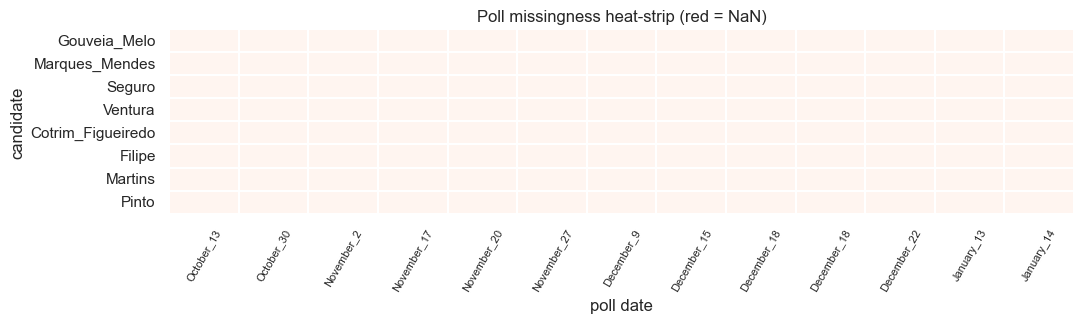

In [13]:
# Speech-segment side: empty / zero-duration / missing-embedding rows.
speech_issues = pd.Series({
    'empty_transcripts': int((speech_all['transcript'].fillna('').str.strip() == '').sum()),
    'zero_or_missing_duration': int((speech_all['duration'].fillna(0) <= 0).sum()),
    'missing_event_date': int(speech_all['event_date'].isna().sum()),
    'missing_text_embedding': int(speech_all['text_embedding'].isna().sum()),
}).rename('count').to_frame()
speech_issues['pct'] = (speech_issues['count'] / len(speech_all) * 100).round(2)
print('Speech-side data issues:')
display(speech_issues)

# Polls side: NaN per candidate column.
poll_nan = polls[[c for c in polls.columns if c in CANDIDATES]].isna().sum().rename('nan_rows').to_frame()
poll_nan['pct'] = (poll_nan['nan_rows'] / len(polls) * 100).round(2)
print('\nPolls — NaN rows per candidate column:')
display(poll_nan.sort_values('nan_rows', ascending=False))

# Heat-strip of poll missingness.
fig, ax = plt.subplots(figsize=(11, 3.4))
sns.heatmap(polls[[c for c in polls.columns if c in CANDIDATES]].isna().T.astype(int),
            cbar=False, cmap='Reds', linewidths=0.3, linecolor='white', ax=ax,
            xticklabels=polls['date'].values)
ax.set_title('Poll missingness heat-strip (red = NaN)')
ax.set_xlabel('poll date'); ax.set_ylabel('candidate')
ax.tick_params(axis='x', rotation=60, labelsize=8)
plt.tight_layout(); plt.show()


## 7. Segment-duration outlier view

ECDF + boxplot of per-segment duration. Flags very short or very long segments that may distort downstream stats.


Per-segment duration quantiles:


,seconds
0.01,20.15
0.05,20.66
0.25,24.64
0.50,32.55
0.75,46.36
0.95,97.65
0.99,132.95


Segments < 0.5s : 0 (0.00%)
Segments > 60s  : 202 (14.36%)


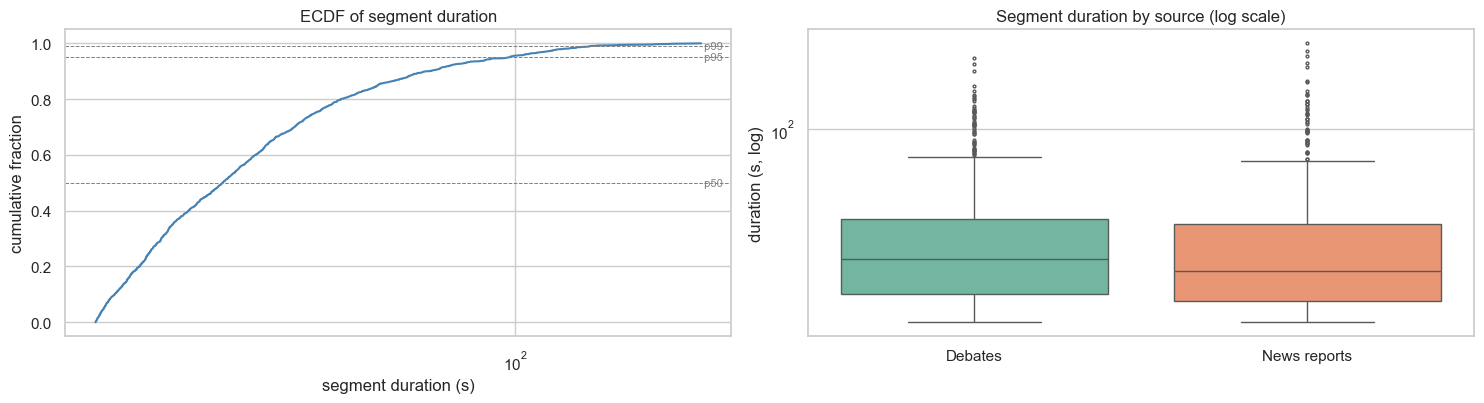

In [14]:
dur = speech_all['duration'].dropna()
quantile_levels = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
quantile_table = dur.quantile(quantile_levels).round(2).to_frame('seconds')
print('Per-segment duration quantiles:')
display(quantile_table)
print(f'Segments < 0.5s : {(dur < 0.5).sum()} ({(dur < 0.5).mean()*100:.2f}%)')
print(f'Segments > 60s  : {(dur > 60).sum()} ({(dur > 60).mean()*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))

# ECDF.
sorted_dur = np.sort(dur.values)
axes[0].plot(sorted_dur, np.linspace(0, 1, len(sorted_dur)), color='steelblue')
for q in [0.5, 0.95, 0.99]:
    axes[0].axhline(q, color='gray', linestyle='--', linewidth=0.7)
    axes[0].text(sorted_dur[-1], q, f' p{int(q*100)}', va='center', fontsize=8, color='gray')
axes[0].set_xlabel('segment duration (s)'); axes[0].set_ylabel('cumulative fraction')
axes[0].set_title('ECDF of segment duration')
axes[0].set_xscale('log')

# Boxplot by source.
sns.boxplot(data=speech_all, x='source_group', y='duration', ax=axes[1],
            hue='source_group', palette='Set2', legend=False, fliersize=2)
axes[1].set_yscale('log')
axes[1].set_title('Segment duration by source (log scale)')
axes[1].set_xlabel(''); axes[1].set_ylabel('duration (s, log)')

plt.tight_layout(); plt.show()


## 8. Debate vs news split

Side-by-side comparison of the two source groups across the metrics that matter for downstream modelling.


Debates vs News reports:


,videos,segments,total_minutes,total_words,mean_words_per_segment,mean_words_per_sec,mean_segment_seconds
source_group,,,,,,,
Debates,28,843,572.36,117328,139.18,3.35,40.74
News reports,14,564,385.85,63129,111.93,2.74,41.05


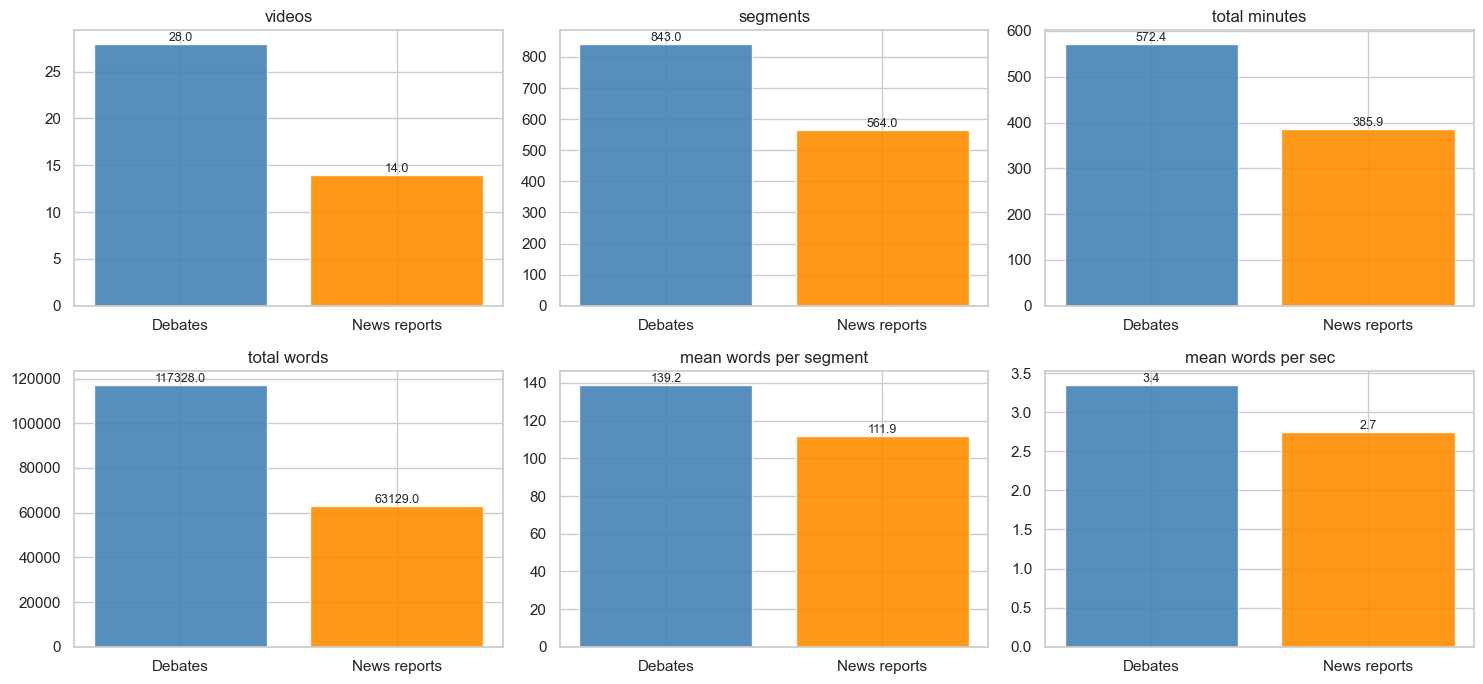

In [15]:
split_metrics = (speech_all.groupby('source_group')
    .agg(videos=('video', 'nunique'),
         segments=('transcript', 'count'),
         total_minutes=('duration', lambda s: s.sum() / 60),
         total_words=('word_count', 'sum'),
         mean_words_per_segment=('word_count', 'mean'),
         mean_words_per_sec=('words_per_sec', 'mean'),
         mean_segment_seconds=('duration', 'mean'))
    .reindex(['Debates', 'News reports']))
print('Debates vs News reports:')
display(split_metrics.round(2))

metrics_to_plot = ['videos', 'segments', 'total_minutes', 'total_words',
                   'mean_words_per_segment', 'mean_words_per_sec']
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for ax, metric in zip(axes, metrics_to_plot):
    vals = split_metrics[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=[source_color_map.get(s, 'gray') for s in vals.index],
                  alpha=0.9)
    ax.set_title(metric.replace('_', ' '))
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.1f}',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()


## 9. Newscast structure (segment-level)

Newscasts are structured very differently from debates: a single anchor introduces multiple short news items punctuated by reporter pieces. The transcript files give us per-segment `timestamp` and `duration`, which is enough to characterise pacing and runtime even though no speaker labels or acoustic features were extracted for newscasts.


Per-newscast inventory:


,video,channel,event_date,segments,speech_minutes,mean_segment_s,median_segment_s,total_words,broadcast_minutes,segments_per_minute,speech_share
0,Telejornal_RTP_Nov_10,RTP,2025-11-10,24,13.20,33.01,27.65,2049,37.53,0.64,0.35
1,Telejornal_RTP_Nov_20,RTP,2025-11-20,26,15.00,34.61,25.76,2438,38.08,0.68,0.39
2,Telejornal_RTP_Dec_2,RTP,2025-12-02,25,21.97,52.73,32.13,3565,44.57,0.56,0.49
3,Telejornal_RTP_Dec_11,RTP,2025-12-11,27,21.45,47.66,34.98,3294,45.21,0.60,0.47
4,Telejornal_RTP_Dec_18,RTP,2025-12-18,10,4.83,28.97,26.58,741,18.70,0.53,0.26
5,Telejornal_RTP_Jan_6,RTP,2026-01-06,25,18.10,43.43,24.37,2732,47.68,0.52,0.38
6,Telejornal_RTP_Jan_13,RTP,2026-01-13,34,21.73,38.34,28.70,3752,49.46,0.69,0.44
7,Telejornal_TVI_Nov_10,TVI,2025-11-10,52,30.64,35.35,29.86,5047,69.92,0.74,0.44
8,Telejornal_TVI_Nov_20,TVI,2025-11-20,63,45.89,43.70,32.01,7362,72.03,0.87,0.64
9,Telejornal_TVI_Dec_2,TVI,2025-12-02,78,54.89,42.22,31.63,9475,88.22,0.88,0.62


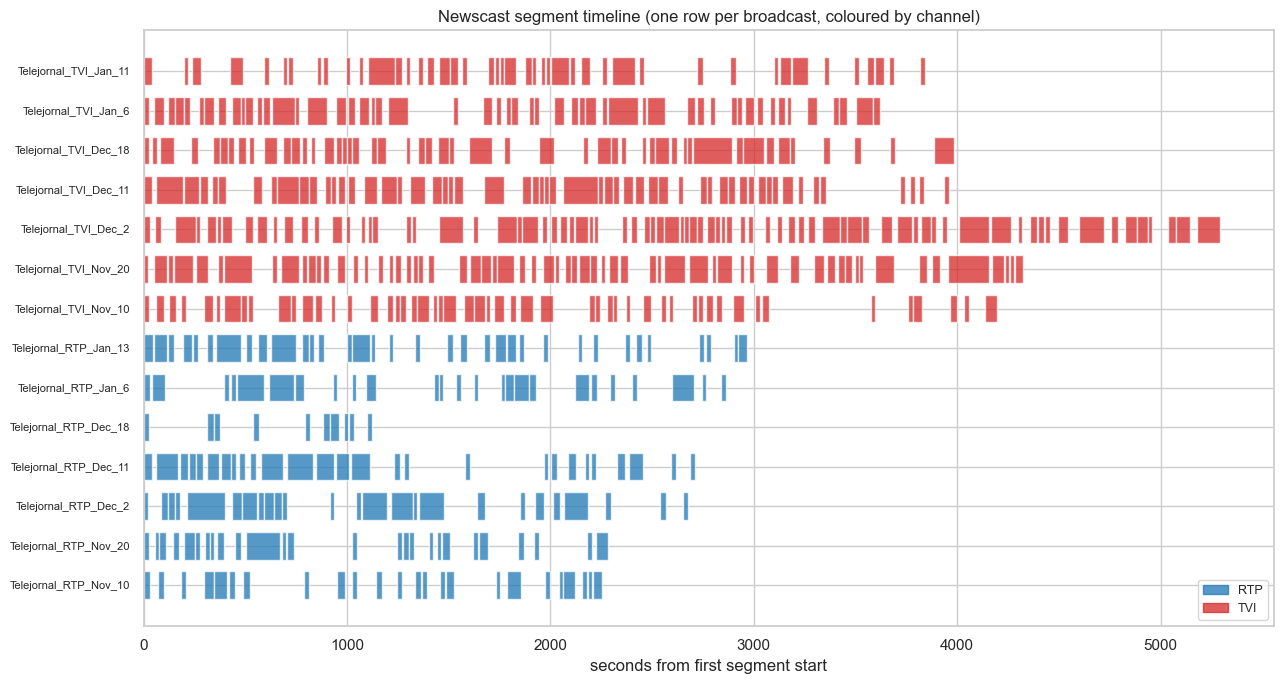

In [16]:
news = speech_all[speech_all['source_type'] == 'jornal'].copy().sort_values(['video', 'timestamp'])

# Wall-clock broadcast extent: time between first segment start and last segment end.
def broadcast_extent(group):
    starts = group['timestamp']
    ends = group['timestamp'] + group['duration'].fillna(0)
    return float(ends.max() - starts.min())

news_inventory = (news.groupby(['video', 'channel', 'event_date'])
    .agg(segments=('transcript', 'count'),
         speech_minutes=('duration', lambda s: s.sum() / 60),
         mean_segment_s=('duration', 'mean'),
         median_segment_s=('duration', 'median'),
         total_words=('word_count', 'sum'))
    .reset_index())
news_inventory['broadcast_minutes'] = (news.groupby('video').apply(broadcast_extent, include_groups=False) / 60).reindex(news_inventory['video']).values
news_inventory['segments_per_minute'] = news_inventory['segments'] / news_inventory['broadcast_minutes'].replace(0, np.nan)
news_inventory['speech_share'] = news_inventory['speech_minutes'] / news_inventory['broadcast_minutes'].replace(0, np.nan)
news_inventory = news_inventory.sort_values(['channel', 'event_date']).reset_index(drop=True)
print('Per-newscast inventory:')
display(news_inventory.round(2))

# Segment timeline (Gantt) — one row per newscast, bars showing segments along broadcast wall-clock.
fig, ax = plt.subplots(figsize=(13, 7))
videos_ordered = news_inventory['video'].tolist()
y_pos = {v: i for i, v in enumerate(videos_ordered)}
channel_color = {'RTP': '#1f77b4', 'TVI': '#d62728'}
for v in videos_ordered:
    g = news[news['video'] == v]
    if g.empty:
        continue
    t0 = g['timestamp'].min()
    starts = (g['timestamp'] - t0).values
    durs = g['duration'].fillna(0).values
    ch = g['channel'].iloc[0]
    ax.barh([y_pos[v]] * len(g), durs, left=starts,
            color=channel_color.get(ch, 'gray'), alpha=0.75, height=0.7)
ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels(videos_ordered, fontsize=8)
ax.set_xlabel('seconds from first segment start')
ax.set_title('Newscast segment timeline (one row per broadcast, coloured by channel)')
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.75, label=ch)
                  for ch, c in channel_color.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()


Inter-segment gap (seconds) summary:
count    550.00
mean      41.71
std       60.07
min        0.02
25%        3.01
50%       20.74
75%       49.92
max      497.49
Name: gap_s, dtype: float64
Negative gaps (overlapping segments): 0

Channel comparison (RTP vs TVI):


,broadcasts,segments,speech_minutes,mean_segment_s,total_words,mean_words_per_sec
channel,,,,,,
RTP,7,171,116.27,40.80,18571,2.72
TVI,7,393,269.58,41.16,44558,2.76


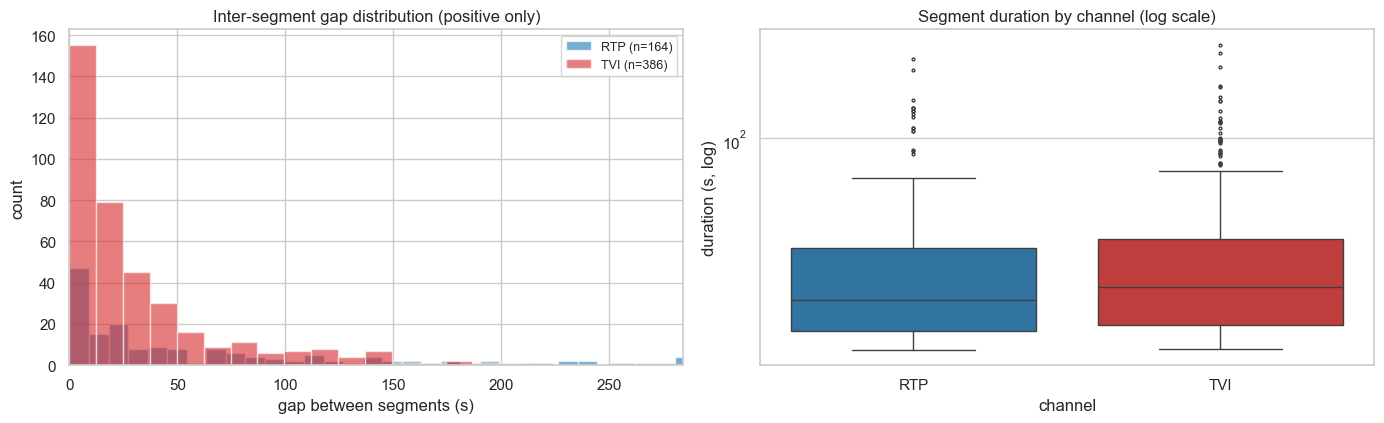

In [17]:
# Inter-segment gap distribution per newscast: gap[i] = start[i+1] - end[i].
gap_rows = []
for v, g in news.groupby('video'):
    g = g.sort_values('timestamp')
    starts = g['timestamp'].values
    ends = (g['timestamp'] + g['duration'].fillna(0)).values
    if len(starts) < 2:
        continue
    gaps = starts[1:] - ends[:-1]
    for gap in gaps:
        gap_rows.append({'video': v, 'channel': g['channel'].iloc[0], 'gap_s': float(gap)})
gap_df = pd.DataFrame(gap_rows)

print('Inter-segment gap (seconds) summary:')
print(gap_df['gap_s'].describe().round(2))
print(f'Negative gaps (overlapping segments): {(gap_df["gap_s"] < 0).sum()}')

# Channel-level comparison.
channel_summary = (news.groupby('channel')
    .agg(broadcasts=('video', 'nunique'),
         segments=('transcript', 'count'),
         speech_minutes=('duration', lambda s: s.sum() / 60),
         mean_segment_s=('duration', 'mean'),
         total_words=('word_count', 'sum'),
         mean_words_per_sec=('words_per_sec', 'mean')))
print('\nChannel comparison (RTP vs TVI):')
display(channel_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))

# (a) Inter-segment gap distribution by channel.
gap_pos = gap_df[gap_df['gap_s'] >= 0]
for ch, color in channel_color.items():
    sub = gap_pos[gap_pos['channel'] == ch]['gap_s']
    if len(sub):
        axes[0].hist(sub, bins=40, alpha=0.6, label=f'{ch} (n={len(sub)})', color=color)
axes[0].set_xlabel('gap between segments (s)'); axes[0].set_ylabel('count')
axes[0].set_title('Inter-segment gap distribution (positive only)')
axes[0].set_xlim(0, np.percentile(gap_pos['gap_s'], 99) if len(gap_pos) else 30)
axes[0].legend(fontsize=9)

# (b) Segment-duration boxplot by channel.
sns.boxplot(data=news, x='channel', y='duration', ax=axes[1],
            hue='channel', palette=channel_color, legend=False, fliersize=2)
axes[1].set_yscale('log')
axes[1].set_title('Segment duration by channel (log scale)')
axes[1].set_ylabel('duration (s, log)')

plt.tight_layout(); plt.show()


## 10. Cross-source vocabulary

Lexical comparison of debates and newscasts. Word clouds + top bigrams highlight what each source talks about; type-token ratio (TTR) per video shows whether one source uses a richer vocabulary than the other.


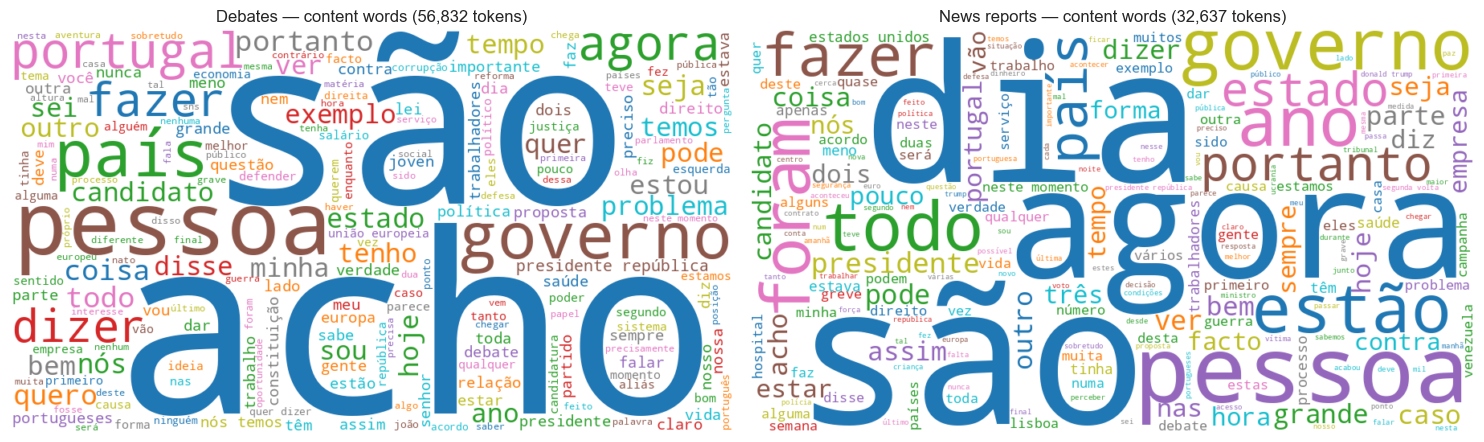

Top-15 content bigrams per source:


,Debates,News reports
0,presidente república (144),estados unidos (55)
1,nós temos (127),neste momento (38)
2,união europeia (82),presidente república (36)
3,quer dizer (57),segunda volta (30)
4,neste momento (52),donald trump (27)
5,nós estamos (40),primeiro ministro (23)
6,primeiro ministro (37),nós temos (21)
7,vou dizer (37),mil euros (21)
8,partido socialista (37),boa noite (20)
9,presente república (36),pacote laboral (17)


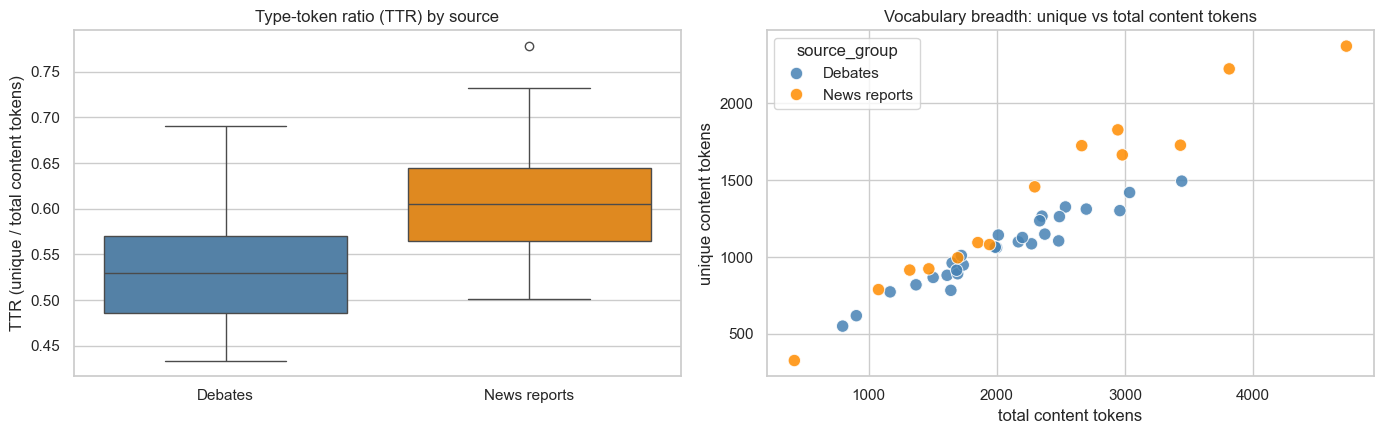


TTR summary by source:


tokens         unique_tokens            TTR       
                  mean  median          mean  median   mean median
source_group                                                      
Debates       2029.714  2005.0      1052.429  1075.0  0.536  0.530
News reports  2331.214  2119.5      1365.929  1275.5  0.615  0.606

In [18]:
from wordcloud import WordCloud

# Lightweight Portuguese stop-word set (debate-filler words handled separately in Part 2).
PT_STOPWORDS_LEX = {
    'a','o','de','que','e','do','da','em','um','para','é','com','não','uma','os','no','se','na','por',
    'mais','as','dos','como','mas','foi','ao','ele','das','à','seu','sua','ou','ser','quando','muito',
    'há','nos','já','está','eu','também','só','pelo','pela','até','isso','ela','entre','era','depois',
    'sem','mesmo','aos','ter','seus','suas','tem','está','vai','vamos','aqui','ali','então','tudo','nada',
    'isso','aqui','sobre','sob','antes','depois','pois','porque','quem','quando','como','onde','porquê',
    'qual','quais','quanto','este','esta','esse','essa','aquele','aquela','isto','aquilo','já','ainda',
    'eh','ah','né','sim','não','ok',
}
WORD_RE_LEX = re.compile(r"[a-záéíóúâêôãõàçü]+", re.IGNORECASE)
def tokenize_lex(text):
    return [w for w in WORD_RE_LEX.findall(str(text).lower())
            if w not in PT_STOPWORDS_LEX and len(w) > 2]

source_tokens = {}
for src in ['Debates', 'News reports']:
    text = ' '.join(speech_all.loc[speech_all['source_group'] == src, 'transcript'].fillna(''))
    source_tokens[src] = tokenize_lex(text)

# Word clouds per source.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (src, toks) in zip(axes, source_tokens.items()):
    if not toks:
        ax.axis('off'); continue
    wc = WordCloud(width=900, height=500, background_color='white',
                   colormap='tab10', random_state=42).generate(' '.join(toks))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{src} — content words ({len(toks):,} tokens)')
    ax.axis('off')
plt.tight_layout(); plt.show()

# Top bigrams per source.
def top_bigrams(toks, n=15):
    grams = [' '.join(toks[i:i+2]) for i in range(len(toks) - 1)]
    return Counter(grams).most_common(n)

bigram_table = pd.DataFrame({
    'Debates': [f'{w} ({c})' for w, c in top_bigrams(source_tokens['Debates'])],
    'News reports': [f'{w} ({c})' for w, c in top_bigrams(source_tokens['News reports'])],
})
print('Top-15 content bigrams per source:')
display(bigram_table)

# Type-token ratio (TTR) per video — measure of vocabulary diversity.
ttr_rows = []
for v, group in speech_all.groupby('video'):
    text = ' '.join(group['transcript'].fillna(''))
    toks = tokenize_lex(text)
    if not toks:
        continue
    ttr_rows.append({
        'video': v,
        'source_group': group['source_group'].iloc[0],
        'tokens': len(toks),
        'unique_tokens': len(set(toks)),
        'TTR': len(set(toks)) / len(toks),
    })
ttr_df = pd.DataFrame(ttr_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=ttr_df, x='source_group', y='TTR', ax=axes[0],
            hue='source_group', palette=source_color_map, legend=False)
axes[0].set_title('Type-token ratio (TTR) by source')
axes[0].set_xlabel(''); axes[0].set_ylabel('TTR (unique / total content tokens)')

sns.scatterplot(data=ttr_df, x='tokens', y='unique_tokens',
                hue='source_group', palette=source_color_map, ax=axes[1], s=80, alpha=0.85)
axes[1].set_title('Vocabulary breadth: unique vs total content tokens')
axes[1].set_xlabel('total content tokens'); axes[1].set_ylabel('unique content tokens')
plt.tight_layout(); plt.show()

print('\nTTR summary by source:')
display(ttr_df.groupby('source_group')[['tokens', 'unique_tokens', 'TTR']].agg(['mean', 'median']).round(3))


## 11. Embedding-norm sanity

L2 norms of the 4096-dim transcript embeddings (and 512-dim speaker embeddings, where loaded). Confirms the embeddings aren't degenerate on short or empty segments before we feed them into PCA / cosine similarity / KMeans.


Transcript-embedding norms (n=1407):
count    1407.000
mean       58.142
std         4.318
min        32.540
25%        55.701
50%        58.428
75%        60.942
max        69.418
dtype: float64
Zero-norm rows: 0

Speaker-embedding norms (sample from Filipe_vs_Pinto_December_8_audio.pkl, n=87):
count    87.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
dtype: float64


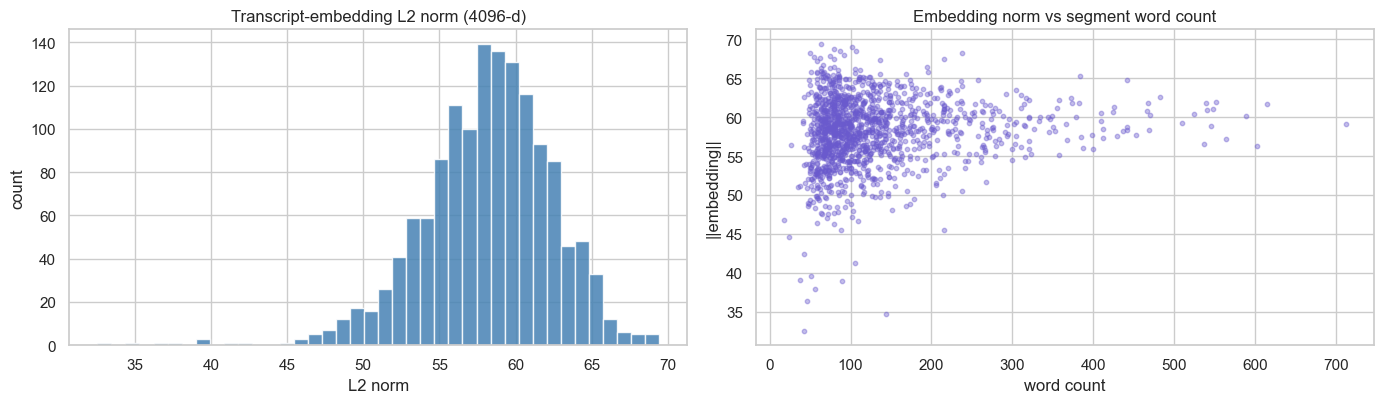

In [19]:
text_norms = np.linalg.norm(np.stack(speech_all['text_embedding'].values), axis=1)
zero_norm = int((text_norms == 0).sum())
print(f'Transcript-embedding norms (n={len(text_norms)}):')
print(pd.Series(text_norms).describe().round(3))
print(f'Zero-norm rows: {zero_norm}')

# Optional: speaker embeddings if any audio file has been loaded already; for Part 1 we read them lazily.
speaker_norms = None
try:
    _audio_files = [f for f in os.listdir(FEAT_DIR)
                    if f.endswith('_audio.pkl') and not f.startswith('Telejornal_')]
    if _audio_files:
        _df = pd.read_pickle(os.path.join(FEAT_DIR, _audio_files[0]))
        if 'speak_embeddings' in _df.columns and len(_df):
            speaker_norms = np.linalg.norm(np.stack(_df['speak_embeddings'].values), axis=1)
            print(f'\nSpeaker-embedding norms (sample from {_audio_files[0]}, n={len(speaker_norms)}):')
            print(pd.Series(speaker_norms).describe().round(3))
except Exception as exc:
    print(f'(speaker-embedding sample skipped: {exc})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].hist(text_norms, bins=40, color='steelblue', alpha=0.85)
axes[0].set_xlabel('L2 norm'); axes[0].set_ylabel('count')
axes[0].set_title('Transcript-embedding L2 norm (4096-d)')

axes[1].scatter(speech_all['word_count'], text_norms, s=10, alpha=0.4, color='slateblue')
axes[1].set_xlabel('word count'); axes[1].set_ylabel('||embedding||')
axes[1].set_title('Embedding norm vs segment word count')
plt.tight_layout(); plt.show()


## 12. Per-video transcript similarity  *(required key plot #3)*

Mean-pool the 4096-dim transcript embedding per video, then compute cosine similarity. Includes both debates and newscasts.


/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


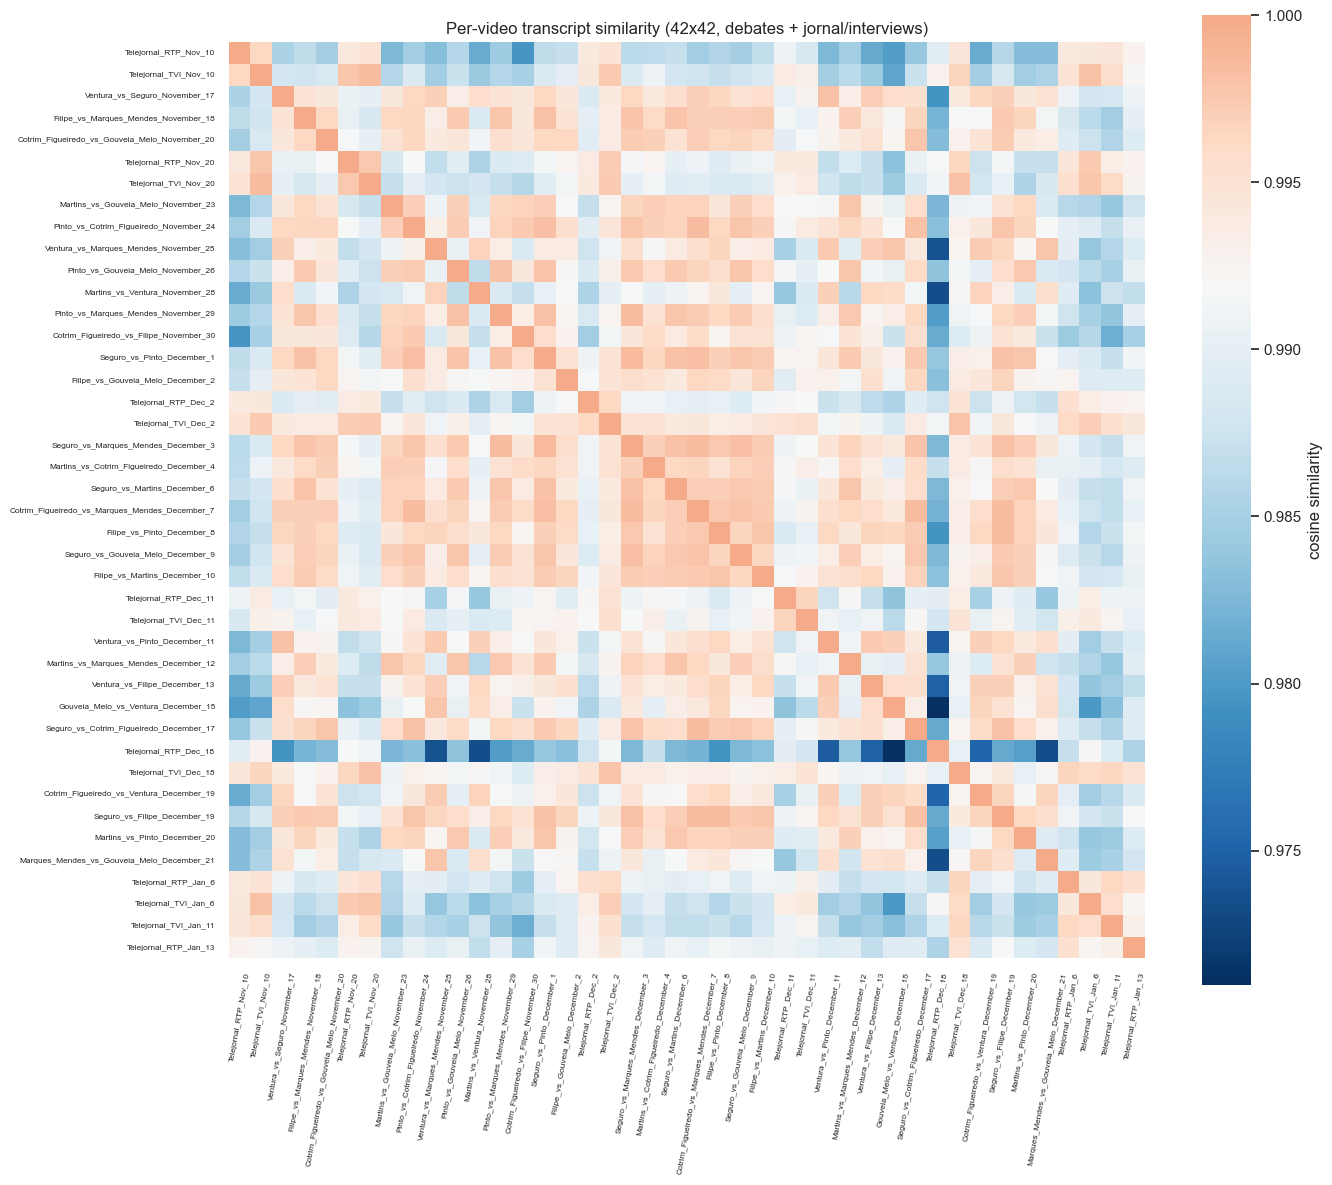

Symmetric: True; diag mean: 1.000
Videos by source group:
source_group
Debates         28
News reports    14


In [20]:
# Per-video mean embedding across debates and jornal/interviews.
video_embed = {}
for v, group in speech_all.groupby('video'):
    video_embed[v] = np.stack(group['text_embedding'].values).mean(axis=0)

video_meta = speech_all.groupby('video').agg(
    event_date=('event_date', 'first'),
    source_group=('source_group', 'first'),
)
videos_sorted = sorted(
    video_embed.keys(),
    key=lambda v: (video_meta.loc[v, 'event_date'] if pd.notna(video_meta.loc[v, 'event_date']) else pd.Timestamp.min, v)
)
video_mat = np.stack([video_embed[v] for v in videos_sorted])
sim_video = cosine_similarity(video_mat)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(sim_video, xticklabels=videos_sorted, yticklabels=videos_sorted,
            cmap='RdBu_r', center=float(sim_video.mean()),
            square=True, ax=ax, cbar_kws={'label': 'cosine similarity'})
ax.set_title(f'Per-video transcript similarity ({len(videos_sorted)}x{len(videos_sorted)}, debates + jornal/interviews)')
ax.tick_params(axis='x', rotation=80, labelsize=6)
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout(); plt.show()

print(f'Symmetric: {np.allclose(sim_video, sim_video.T)}; diag mean: {np.diag(sim_video).mean():.3f}')
print('Videos by source group:')
print(video_meta['source_group'].value_counts().to_string())


## 13. Transcript embedding projection (PCA + t-SNE)

Local neighbourhoods of segments in the 4096-dim space, coloured by source group only — candidate-level colouring lives in Part 2.


Transcript embedding matrix (debates + news reports): (1407, 4096)
PCA explained variance: PC1=17.2%  PC2=10.3%


/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountere

/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountere

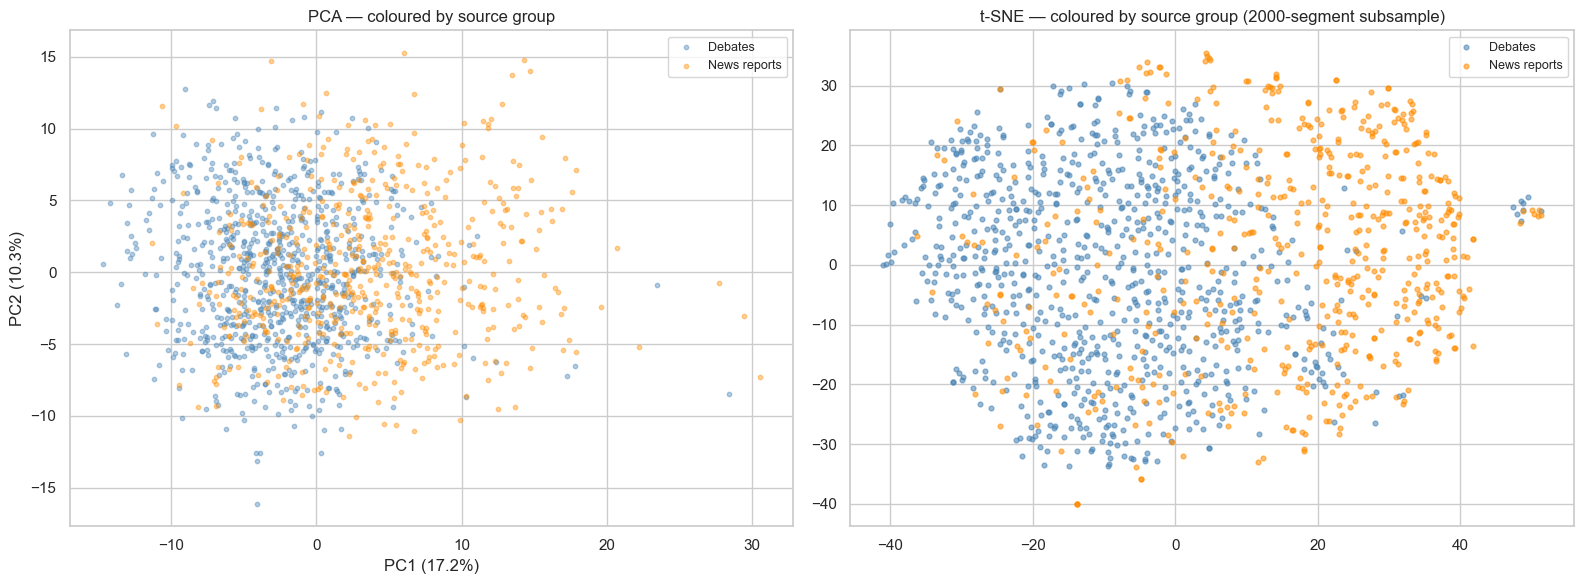

In [21]:
emb_full = np.stack(speech_all['text_embedding'].values)
print(f'Transcript embedding matrix (debates + news reports): {emb_full.shape}')

pca = PCA(n_components=2)
emb_pca = pca.fit_transform(emb_full)
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

rng = np.random.RandomState(42)
sub_idx = rng.choice(len(emb_full), size=min(2000, len(emb_full)), replace=False)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
emb_tsne = tsne.fit_transform(emb_full[sub_idx])

src_arr = speech_all['source_group'].fillna('unknown').values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for src in ['Debates', 'News reports']:
    mask = src_arr == src
    if not mask.any():
        continue
    axes[0].scatter(emb_pca[mask, 0], emb_pca[mask, 1], s=10, alpha=0.4,
                    label=src, color=source_color_map.get(src, 'lightgray'))
axes[0].set_title('PCA — coloured by source group')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=9)

src_sub = src_arr[sub_idx]
for src in ['Debates', 'News reports']:
    mask = src_sub == src
    if not mask.any():
        continue
    axes[1].scatter(emb_tsne[mask, 0], emb_tsne[mask, 1], s=12, alpha=0.55,
                    label=src, color=source_color_map.get(src, 'lightgray'))
axes[1].set_title('t-SNE — coloured by source group (2000-segment subsample)')
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()


## 14. Topic clustering of transcript embeddings (by source)

KMeans on L2-normalised transcript embeddings. We pick `k` by silhouette score and show how topics distribute across the two source groups. The per-candidate ownership view lives in Part 2.


In [22]:
# Minimal Portuguese stop-word filter for naming topics.
PT_STOPWORDS_BASIC = {
    'a','o','de','que','e','do','da','em','um','para','é','com','não','uma','os','no','se','na','por',
    'mais','as','dos','como','mas','foi','ao','ele','das','à','seu','sua','ou','ser','quando','muito',
    'há','nos','já','está','eu','também','só','pelo','pela','até','isso','ela','entre','era','depois',
    'sem','mesmo','aos','ter','seus','suas','tem','está','vai','vamos','aqui','ali','então',
}
WORD_RE = re.compile(r"[a-záéíóúâêôãõàçü]+", re.IGNORECASE)
def tokenize(text):
    return [w for w in WORD_RE.findall(str(text).lower())
            if w not in PT_STOPWORDS_BASIC and len(w) > 2]

emb_full = np.stack(speech_all['text_embedding'].values)
emb_norm = normalize(emb_full)

K_RANGE = range(5, 11)
topic_trials = []
for k in K_RANGE:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(emb_norm)
    sil = silhouette_score(emb_norm, labels, metric='cosine')
    topic_trials.append({'k': k, 'silhouette': sil, 'model': model, 'labels': labels})

topic_score_df = pd.DataFrame([{k: v for k, v in row.items() if k not in {'model', 'labels'}} for row in topic_trials])
print('Topic-cluster silhouette by k:')
display(topic_score_df.round(3))

best_topic = max(topic_trials, key=lambda row: row['silhouette'])
K_TOPICS = int(best_topic['k'])
km_topic = best_topic['model']
speech_all['topic'] = best_topic['labels']

print(f'Chosen K_TOPICS={K_TOPICS} with cosine silhouette={best_topic["silhouette"]:.3f}')
print('Cluster sizes:')
print(speech_all['topic'].value_counts().sort_index().to_string())

topic_top_terms = {}
for k in range(K_TOPICS):
    toks = []
    for text in speech_all.loc[speech_all['topic'] == k, 'transcript'].fillna(''):
        toks.extend(tokenize(text))
    topic_top_terms[k] = [w for w, _ in Counter(toks).most_common(5)]

topic_labels = {k: f'T{k}: ' + ', '.join(topic_top_terms[k][:3]) for k in range(K_TOPICS)}
topic_summary = pd.DataFrame({
    'topic': list(range(K_TOPICS)),
    'label': [topic_labels[k] for k in range(K_TOPICS)],
    'segments': [int((speech_all['topic'] == k).sum()) for k in range(K_TOPICS)],
    'top_terms': [', '.join(topic_top_terms[k]) for k in range(K_TOPICS)],
})
print('\nAutomatic topic labels from top filtered words:')
display(topic_summary)


/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/wo

/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/wo

/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/wo

/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/wo

...

Topic-cluster silhouette by k:


/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,k,silhouette
0,5,0.090
1,6,0.074
2,7,0.073
3,8,0.064
4,9,0.068
5,10,0.056


Chosen K_TOPICS=5 with cosine silhouette=0.090
Cluster sizes:
topic
0    395
1    417
2    224
3    234
4    137

Automatic topic labels from top filtered words:


,topic,label,segments,top_terms
0,0,"T0: dizer, porque, nós",395,"dizer, porque, nós, agora, acho"
1,1,"T1: porque, nós, república",417,"porque, nós, república, acho, país"
2,2,"T2: presidente, esta, estado",224,"presidente, esta, estado, anos, agora"
3,3,"T3: porque, nós, são",234,"porque, nós, são, pessoas, governo"
4,4,"T4: foram, euros, são",137,"foram, euros, são, pessoas, ainda"


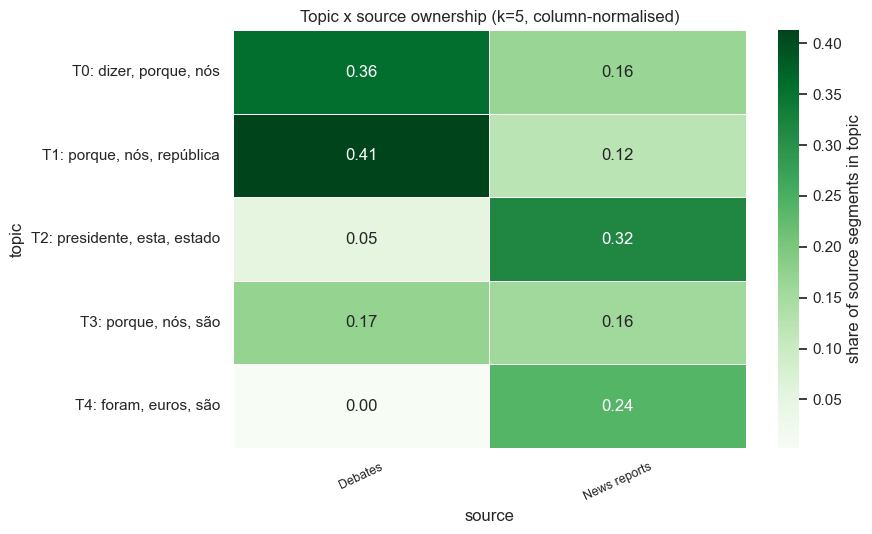

In [23]:
topic_source = (speech_all
                .groupby(['topic', 'source_group']).size()
                .unstack(fill_value=0)
                .reindex(index=range(K_TOPICS), fill_value=0))
source_order = [s for s in ['Debates', 'News reports'] if s in topic_source.columns]
topic_source = topic_source.reindex(columns=source_order)
topic_source_norm = topic_source.div(topic_source.sum(axis=0).replace(0, np.nan), axis=1)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(topic_source_norm, annot=True, fmt='.2f', cmap='Greens',
            cbar_kws={'label': 'share of source segments in topic'},
            linewidths=0.4, ax=ax)
ax.set_title(f'Topic x source ownership (k={K_TOPICS}, column-normalised)')
ax.set_xlabel('source')
ax.set_ylabel('topic')
ax.set_yticklabels([topic_labels[k] for k in topic_source_norm.index], rotation=0)
ax.tick_params(axis='x', rotation=25, labelsize=9)
plt.tight_layout()
plt.show()


## 15. Data quality and sanity checks (Part 1)

Conditions that should hold before this notebook is used downstream. Part 2 has its own per-candidate sanity block.


In [24]:
empty = (speech_all['transcript'].fillna('').str.strip() == '').sum()
shapes = speech_all['text_embedding'].apply(lambda v: np.asarray(v).shape)
unique_shapes = list(shapes.unique())

print(f'Total speech segments:                {len(speech_all)}')
print(f'  by source group:                    {speech_all.groupby("source_group")["video"].nunique().to_dict()}')
print(f'Empty transcripts:                    {empty}')
print(f'Embedding shapes seen:                {unique_shapes}')
print(f'Mean tokens / segment:                {speech_all["word_count"].mean():.1f}')
print(f'Median tokens / segment:              {speech_all["word_count"].median():.1f}')
print(f'Polls long-format rows:               {len(polls_long)}  (expect {len(polls) * len([c for c in polls.columns if c in CANDIDATES])})')
print(f'Per-video similarity symmetric:       {np.allclose(sim_video, sim_video.T)}')


Total speech segments:                1407
  by source group:                    {'Debates': 28, 'News reports': 14}
Empty transcripts:                    0
Embedding shapes seen:                [(4096,)]
Mean tokens / segment:                128.3
Median tokens / segment:              100.0
Polls long-format rows:               104  (expect 104)
Per-video similarity symmetric:       True


---

# Part 2 — Task 2 / 3 Preview *(NOT in midterm slides)*

The cells below assign candidate labels via diarization and run per-candidate / per-party analyses. They belong to Task 2 (Single Video Analysis) and Task 3 (Multi-video & party comparisons), so they are kept here for continuity but are not part of the midterm story.


## 14. Speaker diarization → candidate labels

Debate `*_speech.pkl` files have transcripts and text embeddings, but no speaker/candidate column. The companion debate `*_audio.pkl` files contain 512-dim `speak_embeddings` for the same diarized segments.

Newscast/jornal speech files do not have matching audio speaker-label files, so they are evaluated as source-level transcript text rather than inferred candidate speech.

Workflow:
1. Cluster audio speaker embeddings inside each debate.
2. Constrain the mapping to the two candidates named in the file plus `interviewer`.
3. Iteratively match same-candidate voice centroids across debates.
4. Join candidate labels back to debate speech rows on `(video, timestamp)`.
5. Add jornal/interview transcript rows back with `candidate='jornal/interview'` for source-level analysis.
6. Run diagnostics before using debate candidate labels for candidate-level language claims.


In [25]:
# Backwards-compatible name for debate-only candidate labelling sections.
speech = debate_speech.copy()


In [26]:
CANDIDATES = [
    'Cotrim_Figueiredo', 'Filipe', 'Gouveia_Melo',
    'Marques_Mendes', 'Martins', 'Pinto', 'Seguro', 'Ventura',
]

audio_files = sorted(
    f for f in os.listdir(FEAT_DIR)
    if f.endswith('_audio.pkl') and not f.startswith('Telejornal_')
)
audio_dfs = []
for f in audio_files:
    df = pd.read_pickle(os.path.join(FEAT_DIR, f))
    df['video'] = f.replace('_audio.pkl', '')
    audio_dfs.append(df)
audio = pd.concat(audio_dfs, ignore_index=True)
audio = audio.rename(columns={'time stamp': 'timestamp'})  # align with speech

def extract_candidates(video_name):
    """Return (candA, candB) parsed from filename like 'A_vs_B_Month_Day'."""
    for c in CANDIDATES:
        if video_name.startswith(c):
            rest = video_name[len(c) + len('_vs_'):]
            for c2 in CANDIDATES:
                if rest.startswith(c2):
                    return c, c2
    return None, None

print(f'{len(audio)} audio segments  |  {audio["video"].nunique()} debates')
print('Sanity:', extract_candidates('Ventura_vs_Filipe_December_13'))


2656 audio segments  |  28 debates
Sanity: ('Ventura', 'Filipe')


In [27]:
debate_state = {}
for video_name, group in audio.groupby('video'):
    embs = np.stack(group['speak_embeddings'].values)
    best = None
    for k in (2, 3, 4):
        if len(embs) <= k:
            continue
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(embs)
        sil = silhouette_score(embs, labels, metric='cosine')
        if best is None or sil > best['silhouette']:
            best = {
                'k': k, 'silhouette': sil, 'labels': labels,
                'centroids': km.cluster_centers_, 'index': group.index,
            }
    debate_state[video_name] = best

k_dist = pd.Series([s['k'] for s in debate_state.values()]).value_counts().sort_index()
mean_sil = float(np.mean([s['silhouette'] for s in debate_state.values()]))
print('k chosen across', len(debate_state), 'debates:')
print(k_dist.to_string())
print(f'\nMean silhouette (cosine): {mean_sil:.3f}')

/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/wo

/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/wo

/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/wo

/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/wo

/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/wo

k chosen across 28 debates:
2     1
3    27

Mean silhouette (cosine): 0.548


/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/henrique/conductor/workspaces/big-data/luxembourg/.context/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/henrique/conductor/wo

In [28]:
def cosine(u, v):
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    if nu == 0 or nv == 0:
        return 0.0
    return float(np.dot(u, v) / (nu * nv))


def init_mapping(state, cA, cB):
    sizes = np.bincount(state['labels'], minlength=state['k'])
    by_size = list(np.argsort(-sizes))
    mapping = {int(by_size[0]): cA, int(by_size[1]): cB}
    for c in by_size[2:]:
        mapping[int(c)] = 'interviewer'
    return mapping


assignments = {}
for video_name, state in debate_state.items():
    cA, cB = extract_candidates(video_name)
    if cA is None or cB is None:
        continue
    assignments[video_name] = init_mapping(state, cA, cB)


def global_centroids(assignments, debate_state):
    g = {c: [] for c in CANDIDATES}
    for video_name, mapping in assignments.items():
        st = debate_state[video_name]
        for cluster_id, label in mapping.items():
            if label in g:
                g[label].append(st['centroids'][cluster_id])
    return {c: np.mean(v, axis=0) for c, v in g.items() if v}


def best_mapping(state, cA, cB, gc):
    # Returns mapping plus a confidence gap: best score minus second-best score.
    k = state['k']
    if cA not in gc or cB not in gc:
        return None, -np.inf, np.nan
    gA, gB = gc[cA], gc[cB]
    best_m, best_s, second_s = None, -np.inf, -np.inf
    for a, b in permutations(range(k), 2):
        s = cosine(state['centroids'][a], gA) + cosine(state['centroids'][b], gB)
        if s > best_s:
            second_s = best_s
            best_s = s
            best_m = {a: cA, b: cB}
            for c in range(k):
                if c not in (a, b):
                    best_m[c] = 'interviewer'
        elif s > second_s:
            second_s = s
    return best_m, best_s, best_s - second_s


assignment_scores = {}
assignment_gaps = {}
for it in range(15):
    gc = global_centroids(assignments, debate_state)
    flips = 0
    new_assignments = {}
    for video_name, state in debate_state.items():
        cA, cB = extract_candidates(video_name)
        if cA is None:
            new_assignments[video_name] = assignments.get(video_name)
            continue
        m, score, gap = best_mapping(state, cA, cB, gc)
        if m is None:
            new_assignments[video_name] = assignments[video_name]
            continue
        if m != assignments[video_name]:
            flips += 1
        new_assignments[video_name] = m
        assignment_scores[video_name] = score
        assignment_gaps[video_name] = gap
    assignments = new_assignments
    print(f'iter {it+1}: {flips} flips')
    if flips == 0:
        break

final_gc = global_centroids(assignments, debate_state)
within, between = [], []
for video_name, mapping in assignments.items():
    st = debate_state[video_name]
    for cluster_id, label in mapping.items():
        if label not in final_gc:
            continue
        v = st['centroids'][cluster_id]
        within.append(cosine(v, final_gc[label]))
        for other, gv in final_gc.items():
            if other != label:
                between.append(cosine(v, gv))

print(f'\nMean same-candidate centroid cosine: {np.mean(within):.3f}')
print(f'Mean different-candidate centroid cosine: {np.mean(between):.3f}')
print(f'Voice-separation gap: {np.mean(within) - np.mean(between):.3f}')


iter 1: 17 flips
iter 2: 1 flips
iter 3: 4 flips
iter 4: 0 flips

Mean same-candidate centroid cosine: 0.960
Mean different-candidate centroid cosine: 0.288
Voice-separation gap: 0.672


In [29]:
audio = audio.copy()
audio['candidate'] = 'unknown'
for video_name, state in debate_state.items():
    mapping = assignments.get(video_name)
    if mapping is None:
        continue
    cluster_to_label = np.array([mapping[c] for c in range(state['k'])], dtype=object)
    audio.loc[state['index'], 'candidate'] = cluster_to_label[state['labels']]
audio['party'] = audio['candidate'].map(candidate_to_party).fillna('interviewer')

# Speech timestamps are a strict subset of audio timestamps -> merge on (video, timestamp).
audio_label_features = audio[[
    'video', 'timestamp', 'candidate', 'party',
    'speechrate', 'articulationrate', 'meanF0Hz'
]].copy()

speech_lab = speech.merge(audio_label_features, on=['video', 'timestamp'], how='left')

jornal_lab = jornal_speech.copy()
jornal_lab['candidate'] = JORNAL_LABEL
jornal_lab['party'] = JORNAL_LABEL
for col in ['speechrate', 'articulationrate', 'meanF0Hz']:
    if col not in jornal_lab.columns:
        jornal_lab[col] = np.nan

speech_all_lab = pd.concat([speech_lab, jornal_lab], ignore_index=True, sort=False)

print(f'Debate speech rows after merge: {len(speech_lab)} (input {len(speech)})')
print(f'Unmatched debate rows (NaN candidate): {speech_lab["candidate"].isna().sum()}')
print(f'Combined speech rows after adding jornal/interview: {len(speech_all_lab)}')
print('\nDebate segments per candidate:')
print(speech_lab['candidate'].value_counts().to_string())
print('\nSegments by source group:')
print(speech_all_lab['source_group'].value_counts().to_string())


Debate speech rows after merge: 843 (input 843)
Unmatched debate rows (NaN candidate): 0
Combined speech rows after adding jornal/interview: 1407

Debate segments per candidate:
candidate
interviewer          117
Marques_Mendes       110
Pinto                108
Martins              101
Filipe                98
Ventura               98
Seguro                94
Cotrim_Figueiredo     92
Gouveia_Melo          25

Segments by source group:
source_group
Debates         843
News reports    564


In [30]:
# Keep basic transcript metrics available before candidate-level diagnostics.
speech_lab['word_count'] = speech_lab['transcript'].fillna('').str.split().str.len()
speech_lab['char_count'] = speech_lab['transcript'].fillna('').str.len()
speech_lab['words_per_sec'] = speech_lab['word_count'] / speech_lab['duration'].replace(0, np.nan)

candidate_coverage = (speech_lab.groupby('candidate')
    .agg(segments=('transcript', 'count'),
         total_words=('word_count', 'sum'),
         total_seconds=('duration', 'sum'),
         mean_words=('word_count', 'mean'))
    .sort_values('total_words', ascending=False))
candidate_coverage['word_share_pct'] = 100 * candidate_coverage['total_words'] / candidate_coverage['total_words'].sum()
candidate_coverage['total_minutes'] = candidate_coverage['total_seconds'] / 60
print('Candidate-level transcript coverage (debates only):')
display(candidate_coverage.round({'total_seconds': 1, 'mean_words': 1, 'word_share_pct': 1, 'total_minutes': 1}))

rows = []
for video_name, group in speech_lab.groupby('video'):
    cA, cB = extract_candidates(video_name)
    counts = group['candidate'].value_counts().to_dict()
    words = group.groupby('candidate')['word_count'].sum().to_dict()
    total_words = group['word_count'].sum()
    expected_words = [words.get(c, 0) for c in (cA, cB)]
    expected_counts = [counts.get(c, 0) for c in (cA, cB)]
    min_word_share = min(expected_words) / total_words if total_words else np.nan
    rows.append({
        'video': video_name,
        'expected_candidates': f'{cA} | {cB}',
        'segments': len(group),
        'candidateA_segments': expected_counts[0],
        'candidateB_segments': expected_counts[1],
        'interviewer_segments': counts.get('interviewer', 0),
        'candidateA_words': expected_words[0],
        'candidateB_words': expected_words[1],
        'interviewer_words': words.get('interviewer', 0),
        'min_candidate_word_share': min_word_share,
        'mapping_gap': assignment_gaps.get(video_name, np.nan),
    })

debate_label_diag = pd.DataFrame(rows).sort_values('min_candidate_word_share')
print('Lowest participant coverage by debate (small values need caveats):')
display(debate_label_diag.head(12).round({'min_candidate_word_share': 3, 'mapping_gap': 3}))

assignment_diag = []
for video_name, state in debate_state.items():
    sizes = np.bincount(state['labels'], minlength=state['k'])
    mapping = assignments.get(video_name, {})
    assignment_diag.append({
        'video': video_name,
        'k': state['k'],
        'silhouette': state['silhouette'],
        'mapping_gap': assignment_gaps.get(video_name, np.nan),
        'cluster_sizes': list(map(int, sizes)),
        'mapping': {int(k): v for k, v in mapping.items()},
    })
assignment_diag = pd.DataFrame(assignment_diag).sort_values('mapping_gap')
print('Most ambiguous voice-cluster mappings:')
display(assignment_diag.head(10).round({'silhouette': 3, 'mapping_gap': 3}))

low_coverage = debate_label_diag[debate_label_diag['min_candidate_word_share'] < 0.10]
if len(low_coverage):
    print('\nWarning: some debates have one expected candidate below 10% of transcript words.')
    print('Candidate-level language conclusions for those rows should be treated as lower confidence.')
    print(low_coverage[['video', 'expected_candidates', 'min_candidate_word_share']].to_string(index=False))


Candidate-level transcript coverage (debates only):


,segments,total_words,total_seconds,mean_words,word_share_pct,total_minutes
candidate,,,,,,
Ventura,98,23415,5763.2,238.9,20.0,96.1
Pinto,108,18731,5252.2,173.4,16.0,87.5
Filipe,98,13932,4191.9,142.2,11.9,69.9
Martins,101,13377,4035.1,132.4,11.4,67.3
Cotrim_Figueiredo,92,12899,3767.6,140.2,11.0,62.8
Marques_Mendes,110,11396,3695.8,103.6,9.7,61.6
interviewer,117,10814,3419.7,92.4,9.2,57.0
Seguro,94,10680,3447.4,113.6,9.1,57.5
Gouveia_Melo,25,2084,769.0,83.4,1.8,12.8


Lowest participant coverage by debate (small values need caveats):


,video,expected_candidates,segments,candidateA_segments,candidateB_segments,interviewer_segments,candidateA_words,candidateB_words,interviewer_words,min_candidate_word_share,mapping_gap
8,Gouveia_Melo_vs_Ventura_December_15,Gouveia_Melo | Ventura,21,1,17,3,86,2978,424,0.025,0.411
1,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,Cotrim_Figueiredo | Gouveia_Melo,19,14,1,4,1510,49,317,0.026,0.496
16,Pinto_vs_Gouveia_Melo_November_26,Pinto | Gouveia_Melo,24,14,3,7,2600,253,489,0.076,0.834
20,Seguro_vs_Gouveia_Melo_December_9,Seguro | Gouveia_Melo,17,10,2,5,928,135,492,0.087,0.672
11,Martins_vs_Gouveia_Melo_November_23,Martins | Gouveia_Melo,28,18,5,5,2724,386,410,0.110,0.699
4,Filipe_vs_Gouveia_Melo_December_2,Filipe | Gouveia_Melo,21,10,3,8,1514,281,614,0.117,0.762
7,Filipe_vs_Pinto_December_8,Filipe | Pinto,29,8,15,6,1115,2730,634,0.249,0.502
9,Marques_Mendes_vs_Gouveia_Melo_December_21,Marques_Mendes | Gouveia_Melo,35,20,10,5,2033,894,380,0.270,0.675
17,Pinto_vs_Marques_Mendes_November_29,Pinto | Marques_Mendes,32,16,13,3,2601,1153,284,0.286,0.585
15,Pinto_vs_Cotrim_Figueiredo_November_24,Pinto | Cotrim_Figueiredo,32,16,11,5,2486,1235,465,0.295,0.580


Most ambiguous voice-cluster mappings:


,video,k,silhouette,mapping_gap,cluster_sizes,mapping
27,Ventura_vs_Seguro_November_17,3,0.351,0.288,"[23, 41, 27]","{0: 'Ventura', 1: 'Seguro', 2: 'interviewer'}"
8,Gouveia_Melo_vs_Ventura_December_15,3,0.408,0.411,"[30, 40, 26]","{1: 'Gouveia_Melo', 0: 'Ventura', 2: 'intervie..."
19,Seguro_vs_Filipe_December_19,3,0.496,0.414,"[38, 19, 25]","{0: 'Seguro', 2: 'Filipe', 1: 'interviewer'}"
18,Seguro_vs_Cotrim_Figueiredo_December_17,3,0.393,0.466,"[19, 48, 26]","{1: 'Seguro', 2: 'Cotrim_Figueiredo', 0: 'inte..."
24,Ventura_vs_Filipe_December_13,3,0.475,0.469,"[33, 26, 16]","{1: 'Ventura', 0: 'Filipe', 2: 'interviewer'}"
23,Seguro_vs_Pinto_December_1,3,0.593,0.493,"[36, 34, 25]","{0: 'Seguro', 1: 'Pinto', 2: 'interviewer'}"
1,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,3,0.477,0.496,"[54, 50, 24]","{0: 'Cotrim_Figueiredo', 1: 'Gouveia_Melo', 2:..."
7,Filipe_vs_Pinto_December_8,3,0.507,0.502,"[47, 20, 20]","{0: 'Filipe', 1: 'Pinto', 2: 'interviewer'}"
3,Cotrim_Figueiredo_vs_Ventura_December_19,3,0.391,0.531,"[20, 35, 47]","{2: 'Cotrim_Figueiredo', 1: 'Ventura', 0: 'int..."
6,Filipe_vs_Martins_December_10,3,0.610,0.544,"[36, 26, 31]","{2: 'Filipe', 0: 'Martins', 1: 'interviewer'}"



Candidate-level language conclusions for those rows should be treated as lower confidence.
                                        video              expected_candidates  min_candidate_word_share
          Gouveia_Melo_vs_Ventura_December_15           Gouveia_Melo | Ventura                  0.024656
Cotrim_Figueiredo_vs_Gouveia_Melo_November_20 Cotrim_Figueiredo | Gouveia_Melo                  0.026119
            Pinto_vs_Gouveia_Melo_November_26             Pinto | Gouveia_Melo                  0.075703
            Seguro_vs_Gouveia_Melo_December_9            Seguro | Gouveia_Melo                  0.086817


## 15. Per-candidate transcript volume

Word-count / duration / speech-rate distributions and totals per candidate.


In [31]:
# Recompute on labelled frames so the per-candidate cells are self-contained.
for df in (speech_lab, speech_all_lab):
    df['word_count'] = df['transcript'].fillna('').str.split().str.len()
    df['char_count'] = df['transcript'].fillna('').str.len()
    df['words_per_sec'] = df['word_count'] / df['duration'].replace(0, np.nan)

candidate_text_summary = (speech_lab[speech_lab['candidate'].isin(CANDIDATES)]
    .groupby('candidate')
    .agg(segments=('transcript', 'count'),
         total_words=('word_count', 'sum'),
         total_minutes=('duration', lambda s: s.sum() / 60),
         median_words=('word_count', 'median'),
         mean_words_per_sec=('words_per_sec', 'mean'))
    .sort_values('total_words', ascending=False))
print('Candidate transcript volume (debates only):')
display(candidate_text_summary.round(2))


Candidate transcript volume (debates only):


,segments,total_words,total_minutes,median_words,mean_words_per_sec
candidate,,,,,
Ventura,98,23415,96.05,207.0,4.03
Pinto,108,18731,87.54,139.0,3.59
Filipe,98,13932,69.87,118.0,3.30
Martins,101,13377,67.25,123.0,3.33
Cotrim_Figueiredo,92,12899,62.79,123.5,3.43
Marques_Mendes,110,11396,61.60,94.0,3.07
Seguro,94,10680,57.46,97.5,3.10
Gouveia_Melo,25,2084,12.82,81.0,2.77


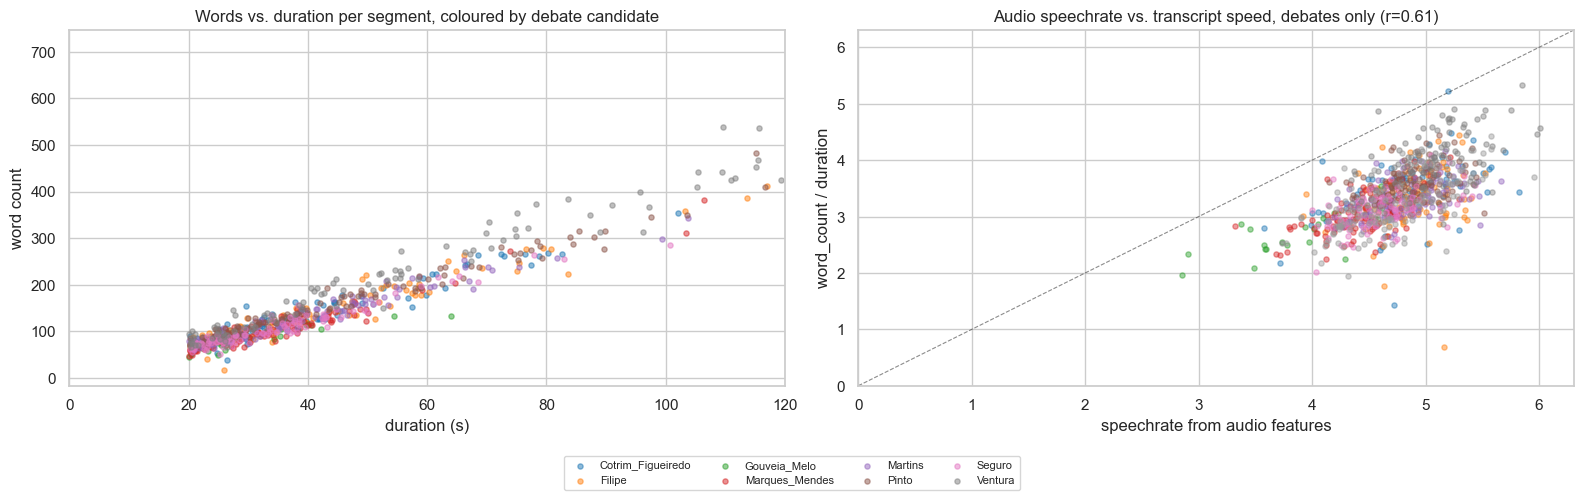

In [32]:
candidates_present = [c for c in CANDIDATES if c in speech_lab['candidate'].unique()]
palette = sns.color_palette('tab10', len(candidates_present))
color_map = dict(zip(candidates_present, palette))
color_map['interviewer'] = (0.6, 0.6, 0.6)
color_map[JORNAL_LABEL] = 'darkorange'
source_color_map = {'Debates': 'steelblue', 'News reports': 'darkorange'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for cand in candidates_present:
    sub = speech_lab[speech_lab['candidate'] == cand]
    axes[0].scatter(sub['duration'], sub['word_count'],
                    s=14, alpha=0.5, label=cand, color=color_map[cand])
axes[0].set_xlabel('duration (s)')
axes[0].set_ylabel('word count')
axes[0].set_title('Words vs. duration per segment, coloured by debate candidate')
axes[0].set_xlim(0, 120)

rate_df = speech_lab.dropna(subset=['speechrate', 'words_per_sec'])
for cand in candidates_present + ['interviewer']:
    sub = rate_df[rate_df['candidate'] == cand]
    if len(sub) == 0:
        continue
    axes[1].scatter(sub['speechrate'], sub['words_per_sec'],
                    s=14, alpha=0.45, label=cand, color=color_map.get(cand, 'lightgray'))
if len(rate_df):
    lim_max = max(rate_df['speechrate'].max(), rate_df['words_per_sec'].max()) * 1.05
    axes[1].plot([0, lim_max], [0, lim_max], 'k--', lw=0.8, alpha=0.5)
    axes[1].set_xlim(0, lim_max)
    axes[1].set_ylim(0, lim_max)
    corr_rate = rate_df[['speechrate', 'words_per_sec']].corr().iloc[0, 1]
    axes[1].set_title(f'Audio speechrate vs. transcript speed, debates only (r={corr_rate:.2f})')
else:
    axes[1].set_title('Audio speechrate unavailable')
axes[1].set_xlabel('speechrate from audio features')
axes[1].set_ylabel('word_count / duration')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=8, ncol=4, loc='lower center')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


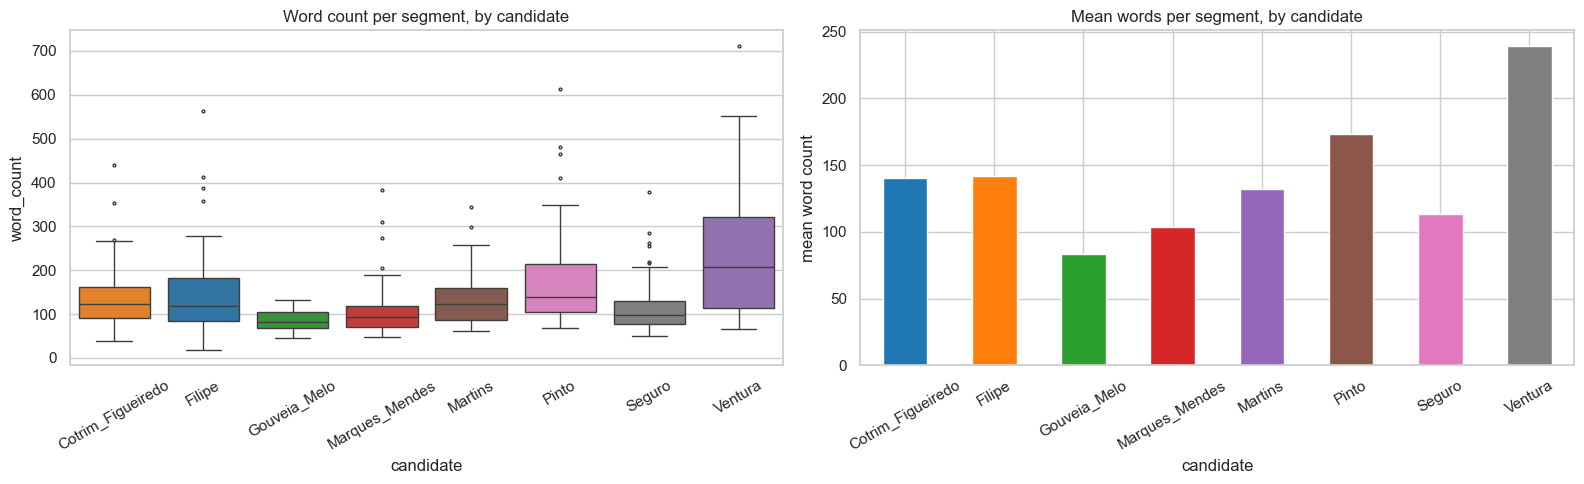

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_df = speech_lab[speech_lab['candidate'].isin(candidates_present)]
sns.boxplot(data=plot_df, x='candidate', y='word_count',
            order=candidates_present, ax=axes[0], hue='candidate',
            palette='tab10', legend=False, fliersize=2)
axes[0].set_title('Word count per segment, by candidate'); axes[0].tick_params(axis='x', rotation=30)

mean_words = (plot_df.groupby('candidate')['word_count']
              .mean().reindex(candidates_present))
mean_words.plot(kind='bar', ax=axes[1], color=[color_map[c] for c in candidates_present])
axes[1].set_title('Mean words per segment, by candidate')
axes[1].set_ylabel('mean word count'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 16. Language patterns: normalized words, phrases, and TF-IDF

Raw word counts are biased by how much transcript coverage each candidate has. This candidate-language section is debate-only because jornal/interview transcripts are not speaker-labelled. It uses:

- content-word frequencies normalized per 1,000 candidate tokens
- bigrams to capture phrases/themes better than isolated words
- candidate-vs-average TF-IDF scores for distinctive vocabulary

Generic debate filler words are removed so the lists are more interpretable.


In [34]:
PT_STOPWORDS = {
    'a','o','de','que','e','do','da','em','um','para','é','com','não','uma','os','no','se','na','por',
    'mais','as','dos','como','mas','foi','ao','ele','das','à','seu','sua','ou','ser','quando','muito',
    'há','nos','já','está','eu','também','só','pelo','pela','até','isso','ela','entre','era','depois',
    'sem','mesmo','aos','ter','seus','suas','numa','nem','meu','às','minha','têm','pelos','elas','havia',
    'seja','qual','será','nós','tenho','lhe','deles','essas','esses','pelas','este','fosse','dele','tu',
    'te','vos','lhes','meus','minhas','teu','tua','teus','tuas','nosso','nossa','nossos','nossas',
    'dela','delas','esta','estes','estas','aquele','aquela','aqueles','aquelas','isto','aquilo','estou',
    'estamos','estão','estive','esteve','estivemos','estiveram','tinha','tínhamos','tinham','sou',
    'somos','são','éramos','eram','fui','fomos','foram','tenha','tenhamos','tenham','aí','sim',
    'então','agora','aqui','ali','assim','bem','pouco','menos','tanto','tão','onde','porque',
    'porquê','quem','quais','quanto','quantos','sempre','nunca','talvez','vai','vou','vamos',
    'tem','sr','dr','dra','sra','não','ah','eh','né','vamos','aqui','ou','tudo','nada','algo',
    'pois','antes','sobre','sob','contra','desde','dois','duas','três','algum','alguma','outras',
    'outros','outro','outra','toda','todo','todos','todas','cada','muitos','muitas','poucos','poucas',
    'eles','elas','vocês','você','senhor','senhora','não','no','já','aqui','ali','lá','tá','tô','sei',
    'acho','sabe','olha','vê','vê','né','tipo','assim','enfim','agora','depois','hoje','ontem','amanhã',
}

FILLER_STOPWORDS = {
    'dizer', 'fazer', 'coisa', 'coisas', 'portanto', 'temos', 'quero', 'quer', 'pode', 'podem',
    'ver', 'acho', 'disse', 'dizia', 'digo', 'falar', 'falou', 'senhores', 'senhoras', 'questao',
    'questão', 'ponto', 'primeiro', 'segundo', 'seguinte', 'forma', 'parte', 'vez', 'vezes',
    'claro', 'exatamente', 'precisamente', 'repare', 'olhe', 'bom', 'boa', 'noite', 'marcos',
    'luís', 'antonio', 'antónio', 'andre', 'henrique'
}
TEXT_STOPWORDS = PT_STOPWORDS | FILLER_STOPWORDS

WORD_RE = re.compile(r"[a-záéíóúâêôãõàçü]+", re.IGNORECASE)
def tokenize(text):
    return [w for w in WORD_RE.findall(str(text).lower())
            if w not in TEXT_STOPWORDS and len(w) > 2]

corpora = {}
for cand in candidates_present:
    text = ' '.join(speech_lab.loc[speech_lab['candidate'] == cand, 'transcript'].fillna(''))
    corpora[cand] = tokenize(text)

print('Tokens per candidate (after stopwords):')
for c, toks in corpora.items():
    print(f'  {c:20s} {len(toks):8d} tokens   ({len(set(toks)):5d} unique)')

def make_ngrams(tokens, n=2):
    return [' '.join(tokens[i:i+n]) for i in range(max(0, len(tokens) - n + 1))]

bigram_corpora = {c: make_ngrams(toks, 2) for c, toks in corpora.items()}

candidate_token_stats = pd.DataFrame({
    'candidate': list(corpora.keys()),
    'tokens_after_filter': [len(corpora[c]) for c in corpora],
    'unique_tokens': [len(set(corpora[c])) for c in corpora],
}).set_index('candidate')
candidate_token_stats['type_token_ratio'] = (
    candidate_token_stats['unique_tokens'] / candidate_token_stats['tokens_after_filter'].replace(0, np.nan)
)
print('\nToken diversity after filler filtering:')
display(candidate_token_stats.round(3))


Tokens per candidate (after stopwords):
  Cotrim_Figueiredo        5053 tokens   ( 2655 unique)
  Filipe                   5514 tokens   ( 2569 unique)
  Gouveia_Melo              765 tokens   (  563 unique)
  Marques_Mendes           4344 tokens   ( 2030 unique)
  Martins                  5341 tokens   ( 2236 unique)
  Pinto                    7418 tokens   ( 2895 unique)
  Seguro                   4319 tokens   ( 1997 unique)
  Ventura                  8264 tokens   ( 3270 unique)

Token diversity after filler filtering:


,tokens_after_filter,unique_tokens,type_token_ratio
candidate,,,
Cotrim_Figueiredo,5053,2655,0.525
Filipe,5514,2569,0.466
Gouveia_Melo,765,563,0.736
Marques_Mendes,4344,2030,0.467
Martins,5341,2236,0.419
Pinto,7418,2895,0.390
Seguro,4319,1997,0.462
Ventura,8264,3270,0.396


In [35]:
TOP_N = 15

def top_per_1000(items, n=TOP_N):
    cnt = Counter(items)
    denom = max(len(items) / 1000, 1e-9)
    return [(term, count, count / denom) for term, count in cnt.most_common(n)]

top_words = {}
for c, toks in corpora.items():
    top_words[c] = [f'{w} ({rate:.1f}/1k)' for w, _, rate in top_per_1000(toks)]

freq_df = pd.DataFrame(top_words)
print(f'Top-{TOP_N} content words per candidate, normalized per 1,000 filtered tokens:')
display(freq_df)

top_bigrams = {}
for c, grams in bigram_corpora.items():
    top_bigrams[c] = [f'{w} ({rate:.1f}/1k)' for w, _, rate in top_per_1000(grams, n=10)]

bigram_df = pd.DataFrame(top_bigrams)
print('\nTop-10 content bigrams per candidate, normalized per 1,000 filtered bigrams:')
display(bigram_df)


Top-15 content words per candidate, normalized per 1,000 filtered tokens:


,Cotrim_Figueiredo,Filipe,Gouveia_Melo,Marques_Mendes,Martins,Pinto,Seguro,Ventura
0,pessoas (7.9/1k),república (15.4/1k),estado (11.8/1k),república (7.4/1k),país (12.4/1k),república (15.0/1k),país (11.3/1k),país (10.6/1k)
1,essa (6.1/1k),presidente (10.7/1k),portugueses (9.2/1k),presidente (7.4/1k),portugal (11.6/1k),país (12.8/1k),momento (6.5/1k),portugal (8.8/1k)
2,estado (5.5/1k),trabalhadores (9.6/1k),presidência (7.8/1k),governo (7.1/1k),pessoas (9.7/1k),portugal (9.4/1k),república (6.0/1k),pessoas (8.3/1k)
3,anos (5.1/1k),governo (7.8/1k),essa (7.8/1k),estado (6.0/1k),república (9.4/1k),essa (8.8/1k),governo (5.8/1k),partido (6.5/1k)
4,governo (4.4/1k),estado (5.8/1k),processo (7.8/1k),importante (5.3/1k),governo (8.2/1k),presidente (8.1/1k),economia (5.6/1k),candidato (5.8/1k)
5,esse (4.2/1k),pessoas (5.4/1k),deve (6.5/1k),tempo (4.8/1k),exemplo (6.7/1k),portugueses (7.4/1k),neste (5.1/1k),estava (5.6/1k)
6,república (4.2/1k),constituição (5.4/1k),ideias (6.5/1k),preciso (4.8/1k),trabalho (6.2/1k),anos (6.2/1k),saúde (5.1/1k),governo (5.6/1k)
7,faz (3.8/1k),creio (5.4/1k),parece (6.5/1k),pessoas (4.4/1k),preciso (5.8/1k),constituição (5.0/1k),situação (4.6/1k),lei (5.4/1k)
8,problemas (3.8/1k),direitos (5.3/1k),autor (6.5/1k),anos (4.4/1k),economia (5.1/1k),verdade (4.4/1k),estado (4.6/1k),dar (5.3/1k)
9,saúde (3.6/1k),essa (5.1/1k),mentos (6.5/1k),momento (4.4/1k),importante (5.1/1k),exemplo (4.3/1k),presidente (4.4/1k),estado (4.7/1k)



Top-10 content bigrams per candidate, normalized per 1,000 filtered bigrams:


,Cotrim_Figueiredo,Filipe,Gouveia_Melo,Marques_Mendes,Martins,Pinto,Seguro,Ventura
0,júlio júlio (2.2/1k),presidente república (7.4/1k),autorilismo marcosmente (3.9/1k),presidente república (3.0/1k),união europeia (2.8/1k),presidente república (6.9/1k),neste momento (4.2/1k),partido socialista (2.5/1k)
1,união europeia (2.0/1k),união europeia (4.0/1k),impulmanciar força (2.6/1k),neste momento (2.3/1k),presidente república (1.5/1k),cima mesa (2.6/1k),país precisa (1.9/1k),catarina martins (1.8/1k)
2,presente república (1.6/1k),direitos trabalhadores (1.6/1k),universo autor (2.6/1k),conselho estado (1.8/1k),assembleia república (1.3/1k),união europeia (2.6/1k),serviço nacional (1.6/1k),mudar constituição (1.7/1k)
3,pés pés (1.4/1k),verdade verdade (1.5/1k),autor risco (2.6/1k),combate corrupção (1.4/1k),presidenta república (1.3/1k),diz respeito (2.0/1k),presidente república (1.4/1k),lei laboral (1.6/1k)
4,presidente república (1.2/1k),pacote laboral (1.3/1k),risco mentes (2.6/1k),ministério público (1.4/1k),debate político (1.1/1k),assembleia república (1.9/1k),sistema político (1.4/1k),bloco esquerda (1.2/1k)
5,trem trem (1.2/1k),presente república (1.3/1k),angola desk (2.6/1k),catarina martins (1.4/1k),presente república (1.1/1k),projeto europeu (1.8/1k),legislação laboral (1.4/1k),dar exemplo (1.1/1k)
6,ministério público (1.0/1k),direito trabalho (0.9/1k),guerra carânio (2.6/1k),combate colupção (1.2/1k),estados unidos (1.1/1k),presente república (1.3/1k),nacional saúde (1.4/1k),ria ria (1.1/1k)
7,estados unidos (1.0/1k),acenar república (0.9/1k),vem fácil (2.6/1k),nesta matéria (0.9/1k),vida pessoas (1.1/1k),revisão constitucional (1.2/1k),partido celista (1.4/1k),imagem imagem (1.0/1k)
8,enquanto candidato (0.8/1k),greva geral (0.9/1k),fácil vem (2.6/1k),dar resposta (0.9/1k),greve geral (0.9/1k),próximas décadas (1.1/1k),situação inicial (1.2/1k),faz sentido (0.8/1k)
9,consoito estado (0.8/1k),poder político (0.9/1k),sistema político (2.6/1k),nenhuma revisão (0.9/1k),neste país (0.9/1k),neste momento (1.1/1k),tempo horas (1.2/1k),essa diferença (0.8/1k)


In [36]:
docs = [' '.join(corpora[c]) for c in candidates_present]
vect = TfidfVectorizer(min_df=1, max_features=5000)
X = vect.fit_transform(docs)
vocab = np.array(vect.get_feature_names_out())
mean_scores = np.asarray(X.mean(axis=0)).ravel()

distinctive = {}
for i, cand in enumerate(candidates_present):
    scores = X[i].toarray().ravel()
    # Candidate-vs-average score: high when a word is strong for this candidate and not generic across all candidates.
    lift = scores - mean_scores
    top_idx = lift.argsort()[::-1][:15]
    distinctive[cand] = [(vocab[j], lift[j]) for j in top_idx if lift[j] > 0]

print('Top-15 most distinctive words (candidate TF-IDF minus average TF-IDF):')
for cand, items in distinctive.items():
    words = ', '.join(w for w, _ in items)
    caution = '  [low transcript coverage]' if candidate_coverage.loc[cand, 'word_share_pct'] < 3 else ''
    print(f'  {cand:20s}  {words}{caution}')


Top-15 most distinctive words (candidate TF-IDF minus average TF-IDF):
  Cotrim_Figueiredo     júlio, trem, pessoas, irs, conseguir, qualquer, pés, problemas, certamente, fom, gêmeos, migrações, anos, faz, esse
  Filipe                creio, trabalhadores, república, presidente, direitos, crec, tap, neoliberal, constituição, facto, verdade, europeia, abril, governo, paz
  Gouveia_Melo          autor, autorilismo, mentos, governação, marcosmente, impulmanciar, angola, presidência, hospitais, ideias, universo, território, processo, internos, apliquem  [low transcript coverage]
  Marques_Mendes        combate, colupção, colrupção, ambição, joão, melhorar, prioridades, queixou, importante, estabilidade, evidentemente, ideia, matéria, deixe, preciso
  Martins               portugal, trabalho, país, pessoas, salário, direita, trabalha, preciso, exemplo, segurança, governo, horas, europa, greve, seguramente
  Pinto                 república, país, portugueses, essa, portugal, calhar, mesa, ma

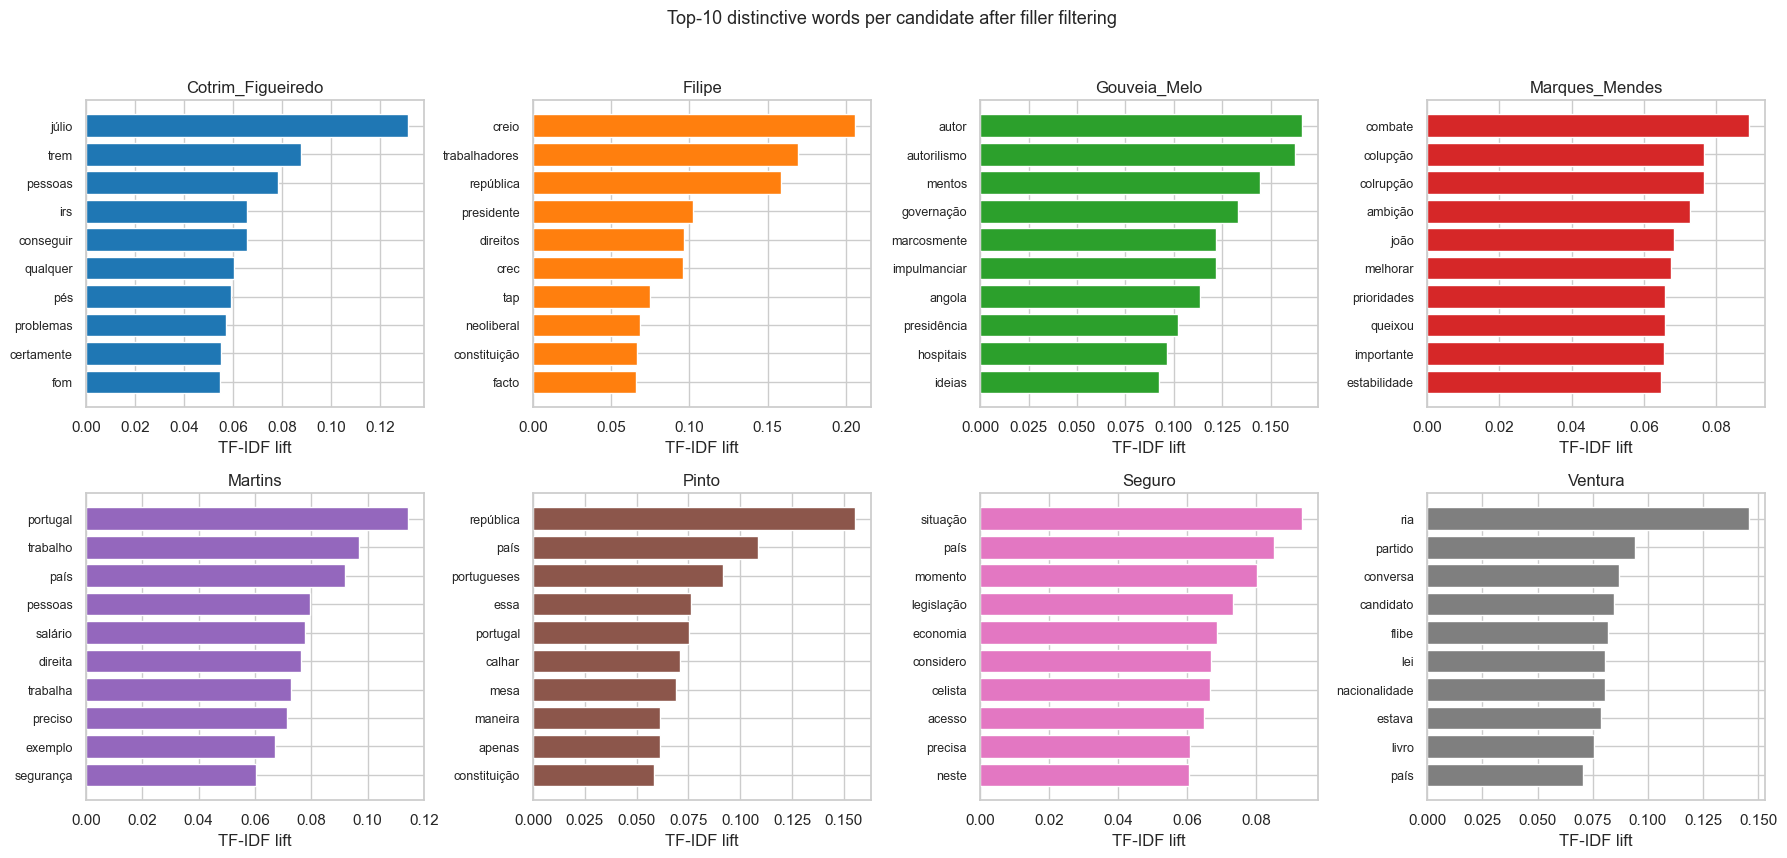

In [37]:
ncols = 4
nrows = int(np.ceil(len(candidates_present) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows))
axes = np.atleast_1d(axes).flatten()
for ax, cand in zip(axes, candidates_present):
    items = distinctive[cand][:10][::-1]
    if not items:
        ax.axis('off')
        continue
    words, scores = zip(*items)
    ax.barh(words, scores, color=color_map[cand])
    ax.set_title(cand)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlabel('TF-IDF lift')
for ax in axes[len(candidates_present):]:
    ax.axis('off')
plt.suptitle('Top-10 distinctive words per candidate after filler filtering', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 17. Latest poll snapshot (by candidate and party)


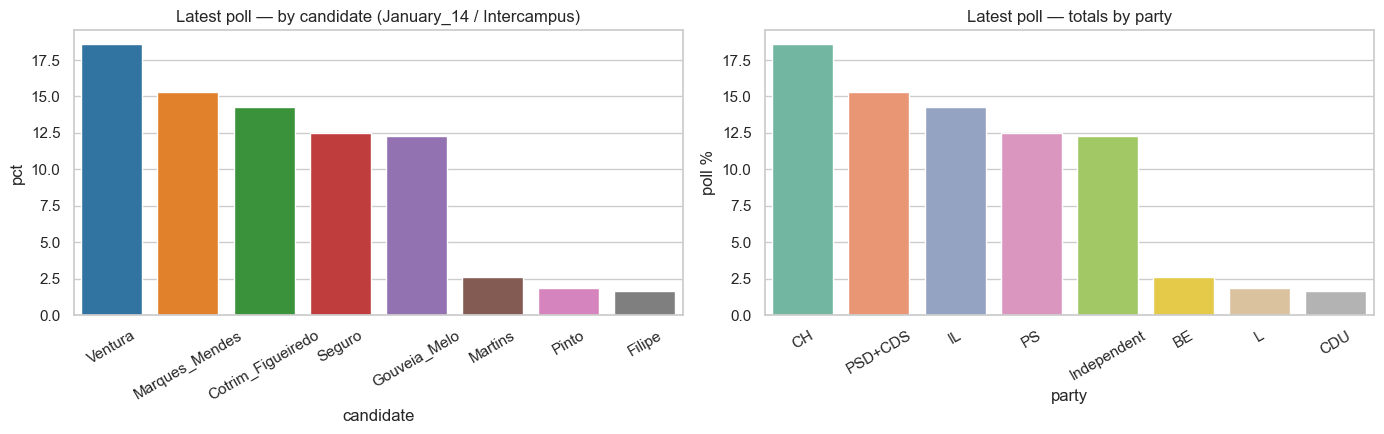

In [38]:
# Latest single poll snapshot (most recent date + source).
latest_row = polls.iloc[-1]
latest = polls_long[(polls_long['date_dt'] == latest_row['date_dt']) &
                    (polls_long['Poll_source'] == latest_row['Poll_source'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=latest.sort_values('pct', ascending=False),
            x='candidate', y='pct', ax=axes[0],
            hue='candidate', palette='tab10', legend=False)
axes[0].set_title(f'Latest poll — by candidate ({latest_row["date"]} / {latest_row["Poll_source"]})')
axes[0].tick_params(axis='x', rotation=30)

by_party = latest.groupby('party')['pct'].sum().sort_values(ascending=False)
sns.barplot(x=by_party.index, y=by_party.values, ax=axes[1],
            hue=by_party.index, palette='Set2', legend=False)
axes[1].set_title('Latest poll — totals by party'); axes[1].set_ylabel('poll %')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 18. Poll movement around debate dates

For every (debate, candidate), the change in poll % between the **7 days after** the debate
and the **7 days before**. Cells where neither window has a poll show as NaN.
Polls are sparse (13 readings across 5 agencies), so this is best read as a *signal* rather
than a precise measurement — but it directly answers "did this debate move the polls?".


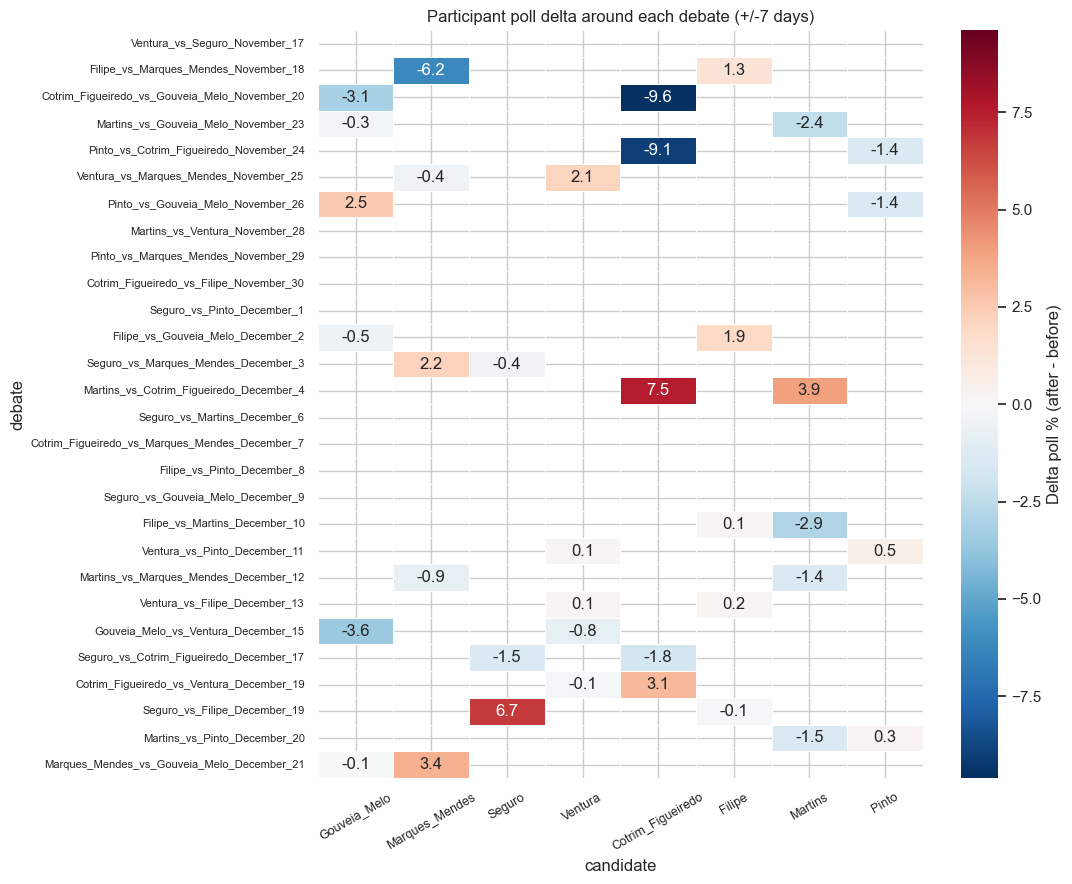

Participant coverage: 38 of 56 debate-participant cells had polls in BOTH windows.
This is an association check only: polls are sparse, agencies differ, and debates are not isolated events.

Mean participant poll delta by candidate:


,mean_delta,median_delta,n
candidate,,,
Seguro,1.60,-0.40,3
Filipe,0.68,0.20,5
Ventura,0.28,0.13,5
Marques_Mendes,-0.38,-0.40,5
Pinto,-0.50,-0.57,4
Gouveia_Melo,-0.84,-0.40,6
Martins,-0.86,-1.47,5
Cotrim_Figueiredo,-1.96,-1.80,5



Largest absolute participant moves (|Delta| >= 1 pp):


,video,candidate,date_dt,delta,is_debate_participant,n_before,n_after
12,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,Cotrim_Figueiredo,2025-11-20,-9.60,True,1,1
124,Pinto_vs_Cotrim_Figueiredo_November_24,Cotrim_Figueiredo,2025-11-24,-9.05,True,2,1
84,Martins_vs_Cotrim_Figueiredo_December_4,Cotrim_Figueiredo,2025-12-04,7.50,True,1,1
154,Seguro_vs_Filipe_December_19,Seguro,2025-12-19,6.70,True,3,1
41,Filipe_vs_Marques_Mendes_November_18,Marques_Mendes,2025-11-18,-6.20,True,1,1
86,Martins_vs_Cotrim_Figueiredo_December_4,Martins,2025-12-04,3.90,True,1,1
64,Gouveia_Melo_vs_Ventura_December_15,Gouveia_Melo,2025-12-15,-3.57,True,1,3
73,Marques_Mendes_vs_Gouveia_Melo_December_21,Marques_Mendes,2025-12-21,3.40,True,3,1
28,Cotrim_Figueiredo_vs_Ventura_December_19,Cotrim_Figueiredo,2025-12-19,3.13,True,3,1
8,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,Gouveia_Melo,2025-11-20,-3.10,True,1,1


In [39]:
WINDOW = pd.Timedelta(days=7)

video_to_date = {v: parse_debate_date(v) for v in speech_lab['video'].unique()}
video_to_date = {v: d for v, d in video_to_date.items() if d is not None}

rows = []
for video, ddate in video_to_date.items():
    debate_candidates = set(extract_candidates(video))
    for cand in cand_cols:
        sub = polls_long[polls_long['candidate'] == cand]
        before = sub[(sub['date_dt'] >= ddate - WINDOW) & (sub['date_dt'] < ddate)]['pct']
        after = sub[(sub['date_dt'] > ddate) & (sub['date_dt'] <= ddate + WINDOW)]['pct']
        delta = (after.mean() - before.mean()) if (len(before) and len(after)) else np.nan
        rows.append({
            'video': video,
            'candidate': cand,
            'date_dt': ddate,
            'delta': delta,
            'is_debate_participant': cand in debate_candidates,
            'n_before': len(before),
            'n_after': len(after),
        })
delta_df = pd.DataFrame(rows)

participant_delta = delta_df[delta_df['is_debate_participant']]
participant_pivot = participant_delta.pivot(index='video', columns='candidate', values='delta')
participant_pivot = participant_pivot.loc[sorted(participant_pivot.index, key=lambda v: video_to_date[v])]
participant_pivot = participant_pivot[[c for c in cand_cols if c in participant_pivot.columns]]

finite_vals = np.abs(participant_pivot.values[np.isfinite(participant_pivot.values)])
vmax = float(finite_vals.max()) if len(finite_vals) else 1.0
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(participant_pivot, annot=True, fmt='.1f', cmap='RdBu_r',
            center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.4, cbar_kws={'label': 'Delta poll % (after - before)'},
            ax=ax)
ax.set_title('Participant poll delta around each debate (+/-7 days)')
ax.set_xlabel('candidate')
ax.set_ylabel('debate')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

print(f'Participant coverage: {participant_delta["delta"].notna().sum()} of {len(participant_delta)} debate-participant cells had polls in BOTH windows.')
print('This is an association check only: polls are sparse, agencies differ, and debates are not isolated events.')

candidate_delta_summary = (participant_delta.dropna(subset=['delta'])
    .groupby('candidate')
    .agg(mean_delta=('delta', 'mean'), median_delta=('delta', 'median'), n=('delta', 'count'))
    .sort_values('mean_delta', ascending=False))
print('\nMean participant poll delta by candidate:')
display(candidate_delta_summary.round(2))

print('\nLargest absolute participant moves (|Delta| >= 1 pp):')
notable = participant_delta.dropna(subset=['delta']).copy()
notable['abs'] = notable['delta'].abs()
display(notable[notable['abs'] >= 1.0]
        .sort_values('abs', ascending=False)
        .drop(columns='abs')
        .head(15)
        .round({'delta': 2}))


## 19. Inter-pollster disagreement

For each polling event, find the readings from *other* agencies within ±5 days for the
same candidate, then compute the std across that small set. Average per candidate.
A high value means agencies disagreed about that candidate's level.


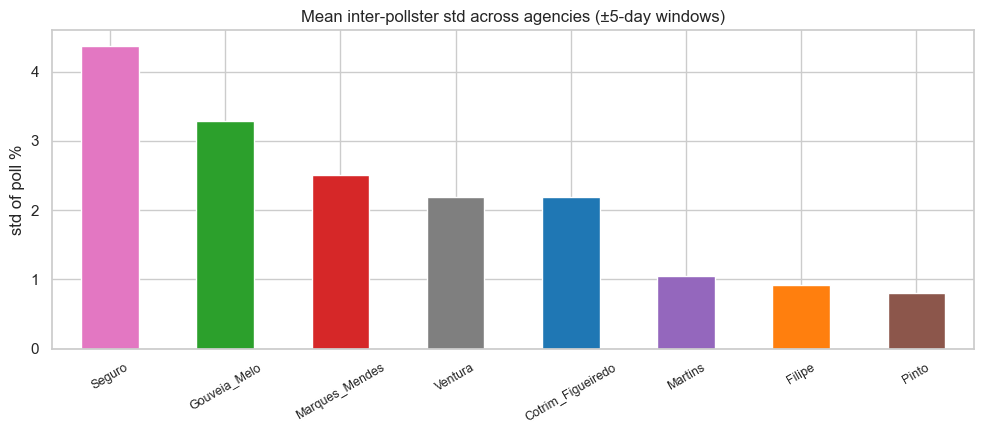

Mean disagreement per candidate (pp):
Seguro               4.38
Gouveia_Melo         3.28
Marques_Mendes       2.51
Ventura              2.20
Cotrim_Figueiredo    2.19
Martins              1.05
Filipe               0.91
Pinto                0.80


In [40]:
WINDOW_DA = pd.Timedelta(days=5)

per_candidate_dis = {}
for cand in cand_cols:
    sub = polls_long[polls_long['candidate'] == cand].sort_values('date_dt')
    stds = []
    for _, row in sub.iterrows():
        peers = sub[(sub['date_dt'] >= row['date_dt'] - WINDOW_DA) &
                    (sub['date_dt'] <= row['date_dt'] + WINDOW_DA) &
                    (sub['Poll_source'] != row['Poll_source'])]
        if len(peers) >= 1:
            vals = np.concatenate([[row['pct']], peers['pct'].values])
            stds.append(float(np.std(vals, ddof=1)))
    if stds:
        per_candidate_dis[cand] = float(np.mean(stds))

dis_series = (pd.Series(per_candidate_dis)
              .reindex(cand_cols)
              .dropna()
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
dis_series.plot(kind='bar', ax=ax,
                color=[color_map.get(c, 'gray') for c in dis_series.index])
ax.set_title('Mean inter-pollster std across agencies (±5-day windows)')
ax.set_ylabel('std of poll %')
ax.tick_params(axis='x', rotation=30, labelsize=9)
plt.tight_layout(); plt.show()

print('Mean disagreement per candidate (pp):')
print(dis_series.round(2).to_string())


## 19b. Inter-agency correlation

Each agency is summarised by its mean poll value per candidate (one 8-vector per agency). Pearson correlations between these profiles tell us which agencies tend to agree on the relative *levels* of the candidates. With only 13 polls split across 5 agencies, individual-poll alignment is too sparse for direct row-wise correlation, so we use mean profiles as the comparison unit. The clustermap groups agencies by similarity of those profiles.


In [ ]:
# Mean candidate % per agency: one row per agency, columns = candidates.
agency_profile = (polls_long
                  .groupby(['Poll_source', 'candidate'])['pct']
                  .mean()
                  .unstack('candidate')
                  .reindex(columns=cand_cols))

print('Agency mean profiles (% per candidate):')
print(agency_profile.round(1))
print('\nReadings per agency:')
print(polls['Poll_source'].value_counts().to_string())

# Pearson correlation between agency profiles.
agency_corr = agency_profile.T.corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(agency_corr, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Inter-agency correlation (mean candidate-% profiles)')
plt.tight_layout(); plt.show()

cg = sns.clustermap(agency_corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    annot=True, fmt='.2f', figsize=(7, 6),
                    cbar_kws={'label': 'Pearson r'})
cg.fig.suptitle('Agency clustering by profile correlation', y=1.02)
plt.show()

# Top / bottom agency pairs.
mask = np.triu(np.ones(agency_corr.shape), k=1).astype(bool)
pairs = (agency_corr.where(mask)
                    .stack()
                    .sort_values(ascending=False))
print('\nMost similar agency pairs:')
print(pairs.head(3).round(2).to_string())
print('\nLeast similar agency pairs:')
print(pairs.tail(3).round(2).to_string())


## 20. Per-candidate transcript similarity


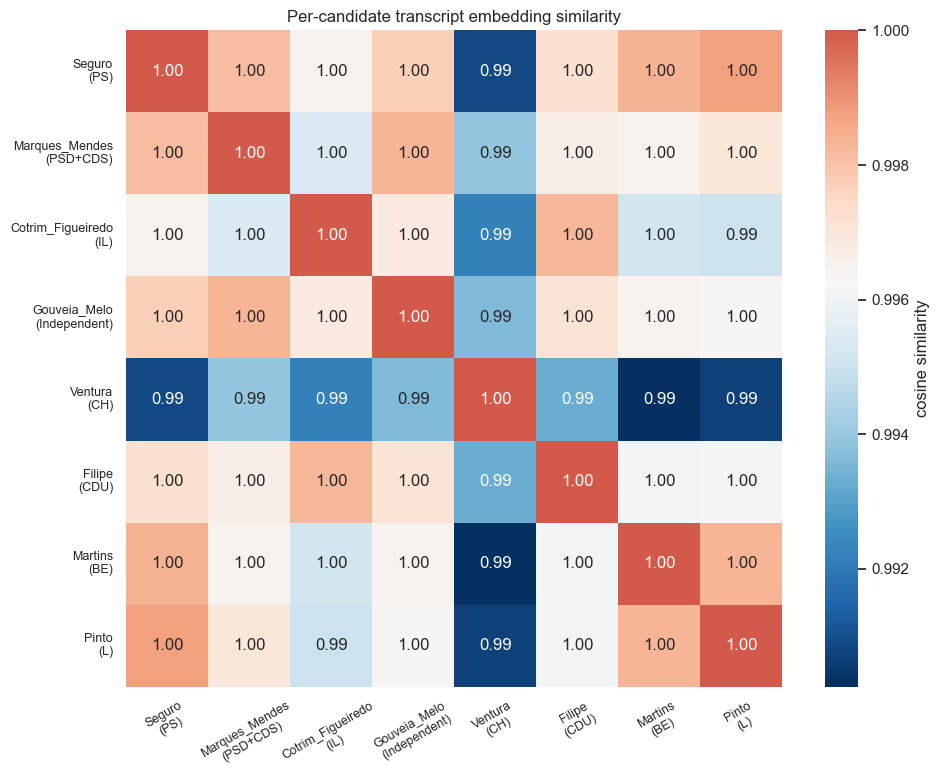

Most similar candidate pairs by transcript embeddings:


,candidate_a,candidate_b,party_a,party_b,embedding_similarity
6,Seguro,Pinto,PS,L,0.999
5,Seguro,Martins,PS,BE,0.998
27,Martins,Pinto,BE,L,0.998
8,Marques_Mendes,Gouveia_Melo,PSD+CDS,Independent,0.998
15,Cotrim_Figueiredo,Filipe,IL,CDU,0.998
0,Seguro,Marques_Mendes,PS,PSD+CDS,0.998
2,Seguro,Gouveia_Melo,PS,Independent,0.998
4,Seguro,Filipe,PS,CDU,0.997


Least similar candidate pairs by transcript embeddings:


,candidate_a,candidate_b,party_a,party_b,embedding_similarity
23,Ventura,Martins,CH,BE,0.990
24,Ventura,Pinto,CH,L,0.991
3,Seguro,Ventura,PS,CH,0.991
14,Cotrim_Figueiredo,Ventura,IL,CH,0.992
22,Ventura,Filipe,CH,CDU,0.993
18,Gouveia_Melo,Ventura,Independent,CH,0.994
9,Marques_Mendes,Ventura,PSD+CDS,CH,0.994
17,Cotrim_Figueiredo,Pinto,IL,L,0.995


In [41]:
PARTY_ORDER = ['PS', 'PSD+CDS', 'IL', 'Independent', 'CH', 'CDU', 'BE', 'L']
cand_order = sorted(candidates_present,
                    key=lambda c: PARTY_ORDER.index(candidate_to_party.get(c, 'Independent')))

cand_embed = {}
for cand in cand_order:
    sub = speech_lab[speech_lab['candidate'] == cand]
    cand_embed[cand] = np.stack(sub['text_embedding'].values).mean(axis=0)
cand_mat = np.stack([cand_embed[c] for c in cand_order])
sim_cand = cosine_similarity(cand_mat)

labels_with_party = [f'{c}\n({candidate_to_party[c]})' for c in cand_order]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_cand, xticklabels=labels_with_party, yticklabels=labels_with_party,
            cmap='RdBu_r', center=float(sim_cand.mean()),
            annot=True, fmt='.2f', square=True, ax=ax,
            cbar_kws={'label': 'cosine similarity'})
ax.set_title('Per-candidate transcript embedding similarity')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

pair_rows = []
for i, j in combinations(range(len(cand_order)), 2):
    pair_rows.append({
        'candidate_a': cand_order[i],
        'candidate_b': cand_order[j],
        'party_a': candidate_to_party[cand_order[i]],
        'party_b': candidate_to_party[cand_order[j]],
        'embedding_similarity': sim_cand[i, j],
    })
embedding_pairs = pd.DataFrame(pair_rows)
print('Most similar candidate pairs by transcript embeddings:')
display(embedding_pairs.sort_values('embedding_similarity', ascending=False).head(8).round(3))
print('Least similar candidate pairs by transcript embeddings:')
display(embedding_pairs.sort_values('embedding_similarity', ascending=True).head(8).round(3))


**Reading the heatmaps.** A reddish off-diagonal cell means two transcript embeddings are more similar than the average pair. The per-video heatmap includes debates and jornal/interview broadcasts; the per-candidate heatmap is debate-only. The baseline is high because every video belongs to the same election context, so the colour scale is centred on the matrix mean rather than 0. Use the pair tables as the concrete finding and the heatmap as the overview.


## 20b. Lexical similarity cross-check

Embedding similarity can capture broad semantic overlap. A TF-IDF similarity matrix checks whether the same conclusion also appears in the surface vocabulary.


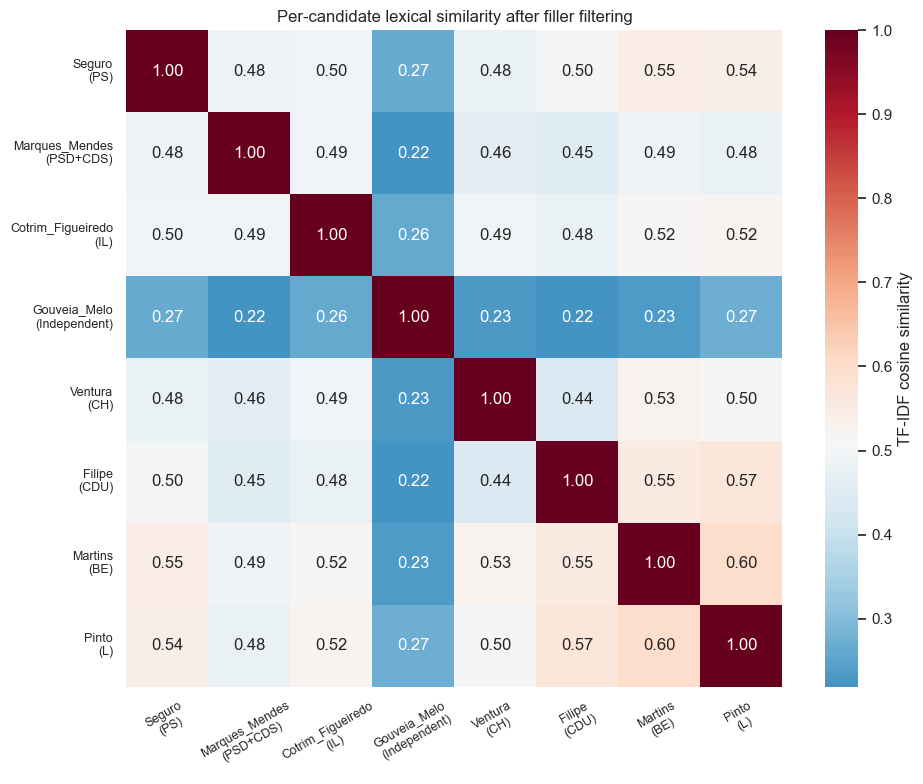

Pairs where semantic similarity is much higher than lexical overlap:


,candidate_a,candidate_b,embedding_similarity,lexical_similarity,difference_embed_minus_lex
8,Marques_Mendes,Gouveia_Melo,0.998,0.219,0.779
19,Gouveia_Melo,Filipe,0.997,0.222,0.775
20,Gouveia_Melo,Martins,0.997,0.235,0.762
18,Gouveia_Melo,Ventura,0.994,0.232,0.762
13,Cotrim_Figueiredo,Gouveia_Melo,0.997,0.261,0.736
2,Seguro,Gouveia_Melo,0.998,0.267,0.731
21,Gouveia_Melo,Pinto,0.996,0.274,0.723
22,Ventura,Filipe,0.993,0.441,0.552


In [42]:
lex_docs = [' '.join(corpora[c]) for c in cand_order]
lex_vect = TfidfVectorizer(min_df=1, max_features=5000)
lex_X = lex_vect.fit_transform(lex_docs)
sim_lex = cosine_similarity(lex_X)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_lex, xticklabels=labels_with_party, yticklabels=labels_with_party,
            cmap='RdBu_r', center=float(sim_lex.mean()),
            annot=True, fmt='.2f', square=True, ax=ax,
            cbar_kws={'label': 'TF-IDF cosine similarity'})
ax.set_title('Per-candidate lexical similarity after filler filtering')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

lex_pairs = []
for i, j in combinations(range(len(cand_order)), 2):
    lex_pairs.append({
        'candidate_a': cand_order[i],
        'candidate_b': cand_order[j],
        'embedding_similarity': sim_cand[i, j],
        'lexical_similarity': sim_lex[i, j],
        'difference_embed_minus_lex': sim_cand[i, j] - sim_lex[i, j],
    })
lex_pairs = pd.DataFrame(lex_pairs)
print('Pairs where semantic similarity is much higher than lexical overlap:')
display(lex_pairs.sort_values('difference_embed_minus_lex', ascending=False).head(8).round(3))


## 21. Topic × candidate ownership

Re-uses the topic clusters from Part 1 §12. Joins them to the candidate-labelled debate frame so we can see which candidate spent the most time in each topic.


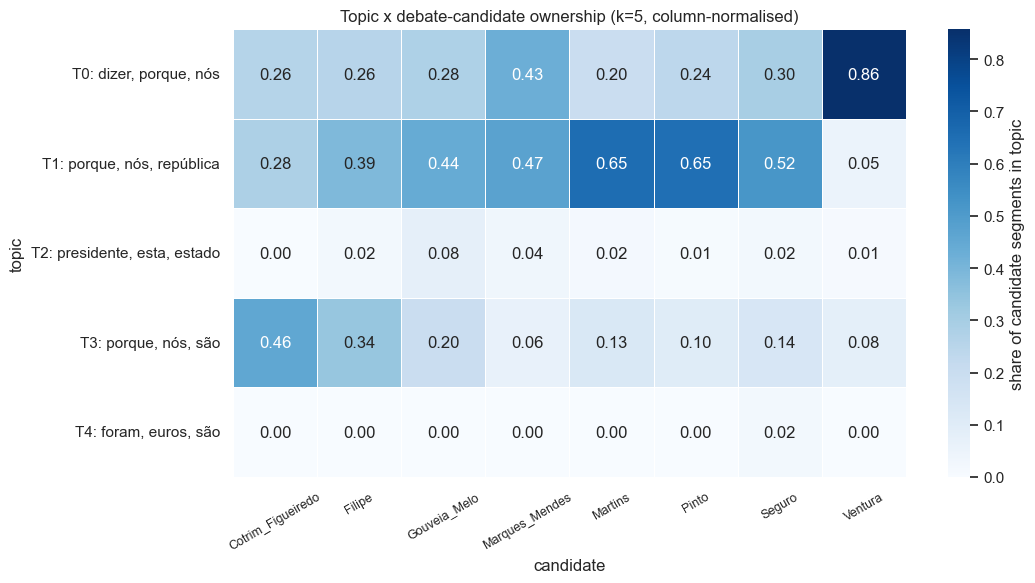

In [43]:
# Bring topic labels from Part 1 into the candidate-labelled debate frame.
speech_lab = speech_lab.drop(columns=['topic'], errors='ignore').merge(
    speech_all.loc[speech_all['source_type'] == 'debate', ['video', 'timestamp', 'topic']],
    on=['video', 'timestamp'], how='left',
)
speech_all_lab = speech_all_lab.drop(columns=['topic'], errors='ignore').merge(
    speech_all[['video', 'timestamp', 'topic']],
    on=['video', 'timestamp'], how='left',
)

candidates_present = [c for c in CANDIDATES if c in speech_lab['candidate'].unique()]
mask = speech_lab['candidate'].isin(candidates_present)
topic_cand = (speech_lab[mask]
              .groupby(['topic', 'candidate']).size()
              .unstack(fill_value=0)
              .reindex(index=range(K_TOPICS), columns=candidates_present, fill_value=0))
topic_cand_norm = topic_cand.div(topic_cand.sum(axis=0).replace(0, np.nan), axis=1)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(topic_cand_norm, annot=True, fmt='.2f', cmap='Blues',
            cbar_kws={'label': 'share of candidate segments in topic'},
            linewidths=0.4, ax=ax)
ax.set_title(f'Topic x debate-candidate ownership (k={K_TOPICS}, column-normalised)')
ax.set_xlabel('candidate'); ax.set_ylabel('topic')
ax.set_yticklabels([topic_labels[k] for k in topic_cand_norm.index], rotation=0)
ax.tick_params(axis='x', rotation=30, labelsize=9)
plt.tight_layout(); plt.show()


## 22. Topic share vs. post-debate poll movement

Joins §5b (Delta poll per debate x candidate) with §7b (topic share per debate x candidate). Topics are learned from debates plus jornal/interview transcripts, but this correlation remains debate-participant-only. For each topic, Pearson correlation of "share of segments in this topic" with "post-debate Delta in poll %". Positive means talking more about that topic associates with poll gains in that debate's aftermath. Sample sizes are small (<= 56 cells), so this is suggestive, not causal.


Correlation between topic share and post-debate participant poll delta:


,topic,topic_label,n,pearson_r,mean_share
0,0,"T0: dizer, porque, nós",33,0.212,0.368
1,1,"T1: porque, nós, república",35,-0.159,0.521
3,3,"T3: porque, nós, são",29,-0.162,0.234
2,2,"T2: presidente, esta, estado",8,-0.459,0.098


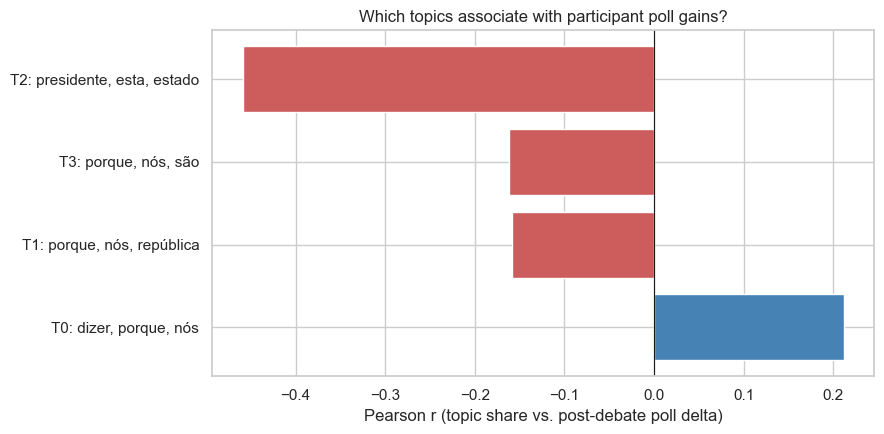

In [44]:
# Per (video, candidate, topic) -> share of that candidate's segments in topic during that debate.
debate_cand_topic = (speech_lab[speech_lab['candidate'].isin(candidates_present)]
                     .groupby(['video', 'candidate', 'topic'])
                     .size().reset_index(name='count'))
total = debate_cand_topic.groupby(['video', 'candidate'])['count'].transform('sum')
debate_cand_topic['share'] = debate_cand_topic['count'] / total

# Bring in participant/non-participant flag and delta from Section 5b.
joined = debate_cand_topic.merge(
    delta_df[['video', 'candidate', 'delta', 'is_debate_participant']].dropna(subset=['delta']),
    on=['video', 'candidate'])
joined = joined[joined['is_debate_participant']]

corr_rows = []
for k in range(K_TOPICS):
    sub = joined[joined['topic'] == k]
    if len(sub) < 5:
        continue
    r = sub[['share', 'delta']].corr().iloc[0, 1]
    corr_rows.append({
        'topic': k,
        'topic_label': topic_labels[k],
        'n': len(sub),
        'pearson_r': float(r),
        'mean_share': sub['share'].mean(),
    })
corr_df = pd.DataFrame(corr_rows).sort_values('pearson_r', ascending=False)

print('Correlation between topic share and post-debate participant poll delta:')
if len(corr_df):
    display(corr_df.round({'pearson_r': 3, 'mean_share': 3}))

    fig, ax = plt.subplots(figsize=(9, 4.5))
    colors = ['steelblue' if r >= 0 else 'indianred' for r in corr_df['pearson_r']]
    ax.barh(corr_df['topic_label'], corr_df['pearson_r'], color=colors)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('Pearson r (topic share vs. post-debate poll delta)')
    ax.set_title('Which topics associate with participant poll gains?')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough matched topic/poll observations to compute correlations.')


## 23. Part 2 sanity checks


In [45]:
join_loss = speech_lab['candidate'].isna().sum()
low_participant_rows = debate_label_diag[debate_label_diag['min_candidate_word_share'] < 0.10]
rate_corr = np.nan
if {'speechrate', 'words_per_sec'}.issubset(speech_lab.columns):
    rate_data = speech_lab.dropna(subset=['speechrate', 'words_per_sec'])
    if len(rate_data) > 2:
        rate_corr = rate_data[['speechrate', 'words_per_sec']].corr().iloc[0, 1]

print(f'Debate speech segments without candidate: {join_loss}')
print(f'Per-candidate similarity symmetric:        {np.allclose(sim_cand, sim_cand.T)}')
print(f'Lexical similarity symmetric:              {np.allclose(sim_lex, sim_lex.T)}')
print(f'Audio/text speed correlation:              {rate_corr:.3f}')
print(f'Debates with low participant coverage:     {len(low_participant_rows)}')

if len(low_participant_rows):
    print('\nRows requiring caveats in candidate-level language claims:')
    print(low_participant_rows[['video', 'expected_candidates', 'min_candidate_word_share']]
          .round({'min_candidate_word_share': 3})
          .to_string(index=False))


Debate speech segments without candidate: 0
Per-candidate similarity symmetric:        True
Lexical similarity symmetric:              True
Audio/text speed correlation:              0.613
Debates with low participant coverage:     4

Rows requiring caveats in candidate-level language claims:
                                        video              expected_candidates  min_candidate_word_share
          Gouveia_Melo_vs_Ventura_December_15           Gouveia_Melo | Ventura                     0.025
Cotrim_Figueiredo_vs_Gouveia_Melo_November_20 Cotrim_Figueiredo | Gouveia_Melo                     0.026
            Pinto_vs_Gouveia_Melo_November_26             Pinto | Gouveia_Melo                     0.076
            Seguro_vs_Gouveia_Melo_December_9            Seguro | Gouveia_Melo                     0.087
